### **Kode Script Model ResNet-50 dengan Selective Kernel Untuk Klasifikasi Spesies Merak Menggunakan Citra Bulu**

-----

## 1. Setup dan Konfigurasi Umum

#### Import Library

In [ ]:
# Library sistem
import os
import json
import random
from pathlib import Path

# Library numerik dan pengolahan data
import numpy as np
import pandas as pd

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library pemrosesan gambar
from PIL import Image

# Library machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Library deep learning
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Pengaturan tampilan
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("Import library berhasil.")
print("Versi TensorFlow:", tf.__version__)

Import library berhasil.
Versi TensorFlow: 2.20.0


#### Mount Google Drive

In [ ]:
# Koneksi Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Define Path

In [ ]:
from pathlib import Path

# Path utama dataset
DATASET_DIR = Path('/content/drive/MyDrive/KodeScript-Arya/Data')

# Nama kelas sesuai folder dataset
class_names = ['Biru (Pavo Cristatus)', 'Hijau (Pavo Muticus)', 'Ungu (Pavo Cristatus mut. purple)']
num_classes = len(class_names)

# Cek ketersediaan path dataset
if DATASET_DIR.exists():
    print(f"Path dataset ditemukan: {DATASET_DIR}")
else:
    print("Path dataset tidak ditemukan, cek kembali!")

# Tampilkan informasi dasar
print(f"Jumlah kelas: {num_classes}")
print(f"Nama kelas : {class_names}")

Path dataset ditemukan: /content/drive/MyDrive/KodeScript-Arya/Data
Jumlah kelas: 3
Nama kelas : ['Biru (Pavo Cristatus)', 'Hijau (Pavo Muticus)', 'Ungu (Pavo Cristatus mut. purple)']


## 2. Pemuatan Data

#### Membaca file gambar dari folder kelas

In [ ]:
# Ekstensi file gambar yang dianggap valid
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# List untuk menyimpan data
filepaths = []
labels = []

# Loop ke setiap folder kelas
for class_name in class_names:
    class_dir = DATASET_DIR / class_name

    # Cek apakah folder kelas tersedia
    if not class_dir.exists():
        print(f"Folder untuk kelas '{class_name}' tidak ditemukan: {class_dir}")
        continue

    # Ambil semua file pada folder kelas
    for file_path in class_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            filepaths.append(str(file_path))
            labels.append(class_name)

print("Pemuatan file gambar selesai.")
print(f"Total file yang berhasil dibaca: {len(filepaths)}")

Pemuatan file gambar selesai.
Total file yang berhasil dibaca: 763


#### Membuat DataFrame hasil pemuatan data

In [ ]:
# Membuat DataFrame dari filepath dan label
df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

# Mengacak urutan data agar lebih netral saat ditinjau
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Menampilkan ringkasan data
print("DataFrame berhasil dibuat.")
print(f"Jumlah total data: {len(df)}")
print("\nJumlah data per kelas:")
print(df["label"].value_counts())

# Menampilkan 5 data teratas
display(df.head())

DataFrame berhasil dibuat.
Jumlah total data: 763

Jumlah data per kelas:
label
Hijau (Pavo Muticus)                 300
Biru (Pavo Cristatus)                300
Ungu (Pavo Cristatus mut. purple)    163
Name: count, dtype: int64


,filepath,label
0,/content/drive/MyDrive/KodeScript-Arya/Data/Hi...,Hijau (Pavo Muticus)
1,/content/drive/MyDrive/KodeScript-Arya/Data/Bi...,Biru (Pavo Cristatus)
2,/content/drive/MyDrive/KodeScript-Arya/Data/Un...,Ungu (Pavo Cristatus mut. purple)
3,/content/drive/MyDrive/KodeScript-Arya/Data/Bi...,Biru (Pavo Cristatus)
4,/content/drive/MyDrive/KodeScript-Arya/Data/Hi...,Hijau (Pavo Muticus)


## 3. Eksplorasi Data

#### Distribusi data per kelas

Distribusi jumlah data per kelas:


,Jumlah,Persentase (%)
label,,
Biru (Pavo Cristatus),300,39.32
Hijau (Pavo Muticus),300,39.32
Ungu (Pavo Cristatus mut. purple),163,21.36


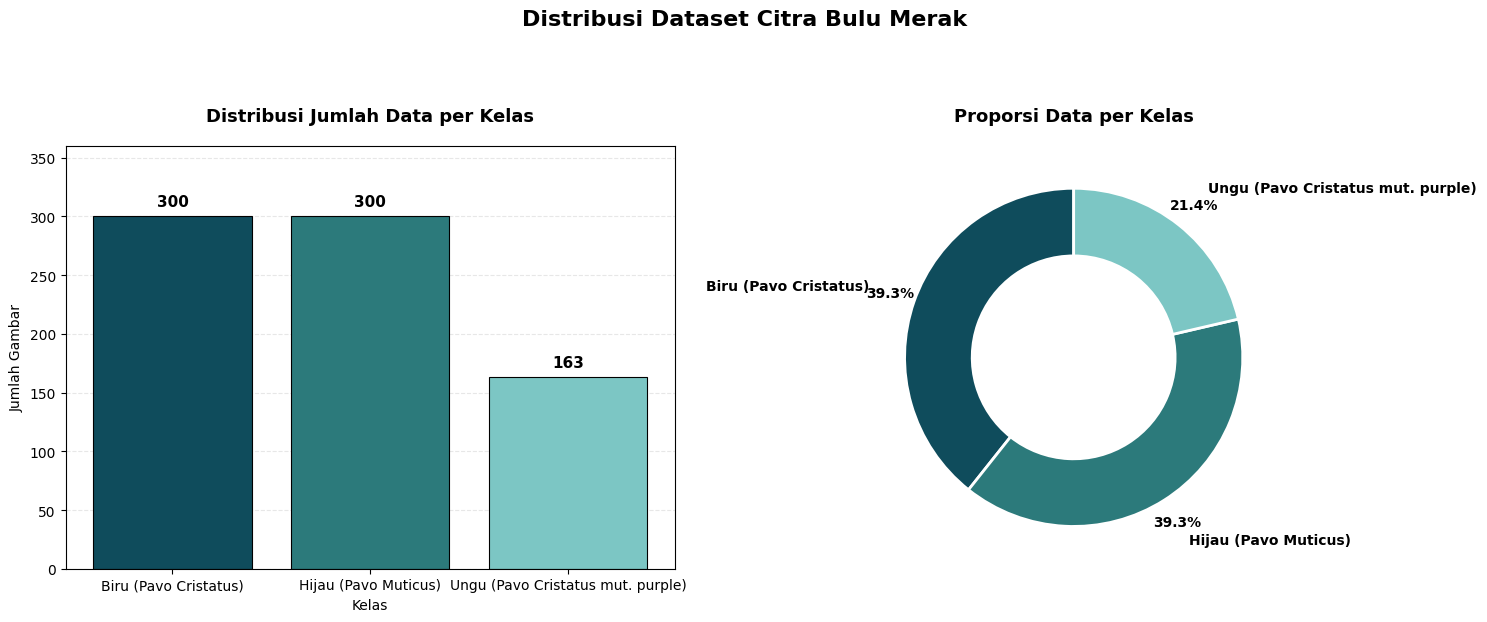

In [ ]:
# Hitung jumlah dan persentase data per kelas
class_distribution = df["label"].value_counts().reindex(class_names)
class_percentages = (class_distribution / class_distribution.sum()) * 100
colors = ["#0F4C5C", "#2C7A7B", "#7CC6C4"]

# Tampilkan tabel ringkasan
distribution_df = pd.DataFrame({
    "Jumlah": class_distribution,
    "Persentase (%)": class_percentages.round(2)
})

print("Distribusi jumlah data per kelas:")
display(distribution_df)

# Membuat visualisasi berdampingan
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)


# BAR CHART JUMLAH DATA
bars = axes[0].bar(
    class_distribution.index,
    class_distribution.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

axes[0].set_title(
    "Distribusi Jumlah Data per Kelas",
    fontsize=13,
    fontweight="bold",
    pad=18
)

axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Gambar")

axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].set_axisbelow(True)

# Tambahkan ruang atas agar label tidak menabrak judul
max_value = class_distribution.max()
axes[0].set_ylim(0, max_value * 1.20)

# Tambahkan label jumlah saja (tanpa persentase)
for bar in bars:
    height = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + (max_value * 0.02),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# DONUT CHART
wedges, texts, autotexts = axes[1].pie(
    class_distribution.values,
    labels=class_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,

    # Persentase dipindah keluar
    pctdistance=1.15,
    labeldistance=1.28,

    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2,
        "width": 0.40
    },

    textprops={
        "fontsize": 10,
        "fontweight": "bold",
        "color": "black"
    }
)

axes[1].set_title(
    "Proporsi Data per Kelas",
    fontsize=13,
    fontweight="bold",
    pad=18
)

# Judul utama
fig.suptitle(
    "Distribusi Dataset Citra Bulu Merak",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Analisis Ukuran Citra

Ringkasan ukuran citra:


,width,height
count,763.0,763.0
mean,2250.0,4000.0
std,0.0,0.0
min,2250.0,4000.0
25%,2250.0,4000.0
50%,2250.0,4000.0
75%,2250.0,4000.0
max,2250.0,4000.0


Jumlah gambar yang gagal dibaca: 0


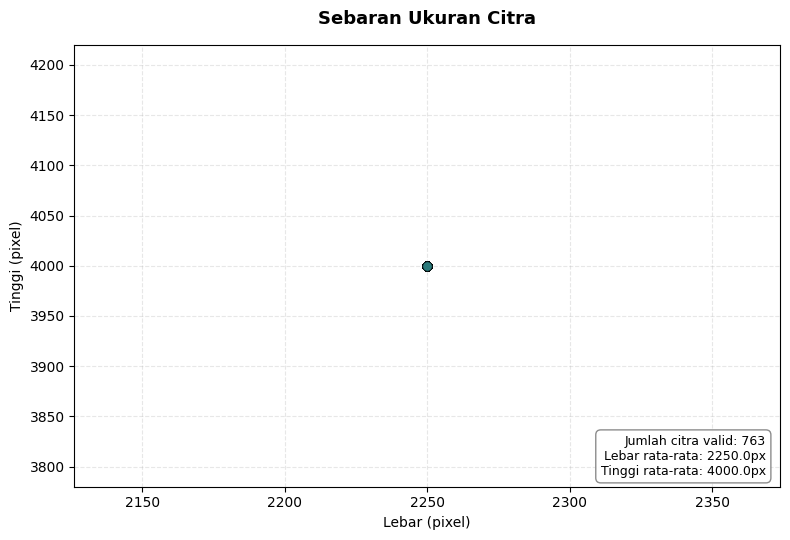

In [ ]:
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# List untuk menyimpan ukuran gambar
image_widths = []
image_heights = []
invalid_images = []

# Baca ukuran masing-masing gambar
for path in df["filepath"]:
    try:
        with Image.open(path) as img:
            width, height = img.size
            image_widths.append(width)
            image_heights.append(height)
    except Exception:
        invalid_images.append(path)

# Membuat DataFrame ukuran citra
size_df = pd.DataFrame({
    "width": image_widths,
    "height": image_heights
})

print("Ringkasan ukuran citra:")
display(size_df.describe().round(2))

print(f"Jumlah gambar yang gagal dibaca: {len(invalid_images)}")

# Warna konsisten dengan visualisasi sebelumnya
colors = ["#0F4C5C", "#2C7A7B", "#7CC6C4"]

# Visualisasi sebaran ukuran
plt.figure(figsize=(8, 5.5))

plt.scatter(
    size_df["width"],
    size_df["height"],
    alpha=0.65,
    s=45,
    color=colors[1],
    edgecolors="black",
    linewidth=0.4
)

plt.title(
    "Sebaran Ukuran Citra",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel("Lebar (pixel)")
plt.ylabel("Tinggi (pixel)")

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

# Tambahkan informasi ringkas di dalam grafik
info_text = (
    f"Jumlah citra valid: {len(size_df)}\n"
    f"Lebar rata-rata: {size_df['width'].mean():.1f}px\n"
    f"Tinggi rata-rata: {size_df['height'].mean():.1f}px"
)

plt.text(
    0.98, 0.02,
    info_text,
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()

#### Preview Gambar

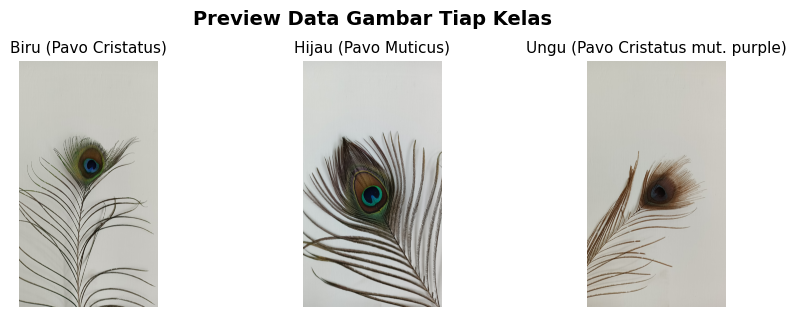

In [ ]:
# Membuat subplot 1 baris sebanyak jumlah kelas
fig, axes = plt.subplots(1, len(class_names), figsize=(9, 3.2))

# Jika hanya 1 kelas, ubah agar tetap iterable
if len(class_names) == 1:
    axes = [axes]

# Judul utama
fig.suptitle("Preview Data Gambar Tiap Kelas", fontsize=14, fontweight="bold", y=0.98)

# Loop per kelas
for i, class_name in enumerate(class_names):
    # Ambil 1 sampel gambar dari tiap kelas
    sample = df[df["label"] == class_name].sample(n=1, random_state=42).iloc[0]
    img_path = sample["filepath"]

    # Baca dan tampilkan gambar
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=11, pad=6)
    axes[i].axis("off")

# Atur jarak antar gambar agar lebih rapat
plt.subplots_adjust(left=0.03, right=0.97, top=0.82, bottom=0.05, wspace=0.02)
plt.show()

## 4. Pembagian Data

#### Split data train, validation, test

In [ ]:
# Training: 80% | Validation: 10% | Testing: 10%
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Pembagian data selesai.")
print(f"Jumlah data train : {len(train_df)}")
print(f"Jumlah data val   : {len(val_df)}")
print(f"Jumlah data test  : {len(test_df)}")

Pembagian data selesai.
Jumlah data train : 610
Jumlah data val   : 76
Jumlah data test  : 77


#### Simpan hasil split to CSV

In [ ]:
# Folder penyimpanan hasil split
SPLIT_DIR = DATASET_DIR.parent / "split_metadata"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

# Path file CSV
train_csv_path = SPLIT_DIR / "train_df.csv"
val_csv_path = SPLIT_DIR / "val_df.csv"
test_csv_path = SPLIT_DIR / "test_df.csv"

# Simpan ke CSV
train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print("Hasil split berhasil disimpan.")
print(f"Train CSV : {train_csv_path}")
print(f"Val CSV   : {val_csv_path}")
print(f"Test CSV  : {test_csv_path}")

Hasil split berhasil disimpan.
Train CSV : /content/drive/MyDrive/KodeScript-Arya/split_metadata/train_df.csv
Val CSV   : /content/drive/MyDrive/KodeScript-Arya/split_metadata/val_df.csv
Test CSV  : /content/drive/MyDrive/KodeScript-Arya/split_metadata/test_df.csv


#### Ringkasan hasil split

In [ ]:
# Ringkasan jumlah data
split_summary = pd.DataFrame({
    "Subset": ["Train", "Validation", "Test"],
    "Jumlah Data": [len(train_df), len(val_df), len(test_df)],
    "Persentase (%)": [
        round(len(train_df) / len(df) * 100, 2),
        round(len(val_df) / len(df) * 100, 2),
        round(len(test_df) / len(df) * 100, 2)
    ]
})

print("Ringkasan pembagian dataset:")
display(split_summary)

# Distribusi kelas pada masing-masing subset
train_dist = train_df["label"].value_counts().reindex(class_names, fill_value=0)
val_dist = val_df["label"].value_counts().reindex(class_names, fill_value=0)
test_dist = test_df["label"].value_counts().reindex(class_names, fill_value=0)

distribution_split_df = pd.DataFrame({
    "Train": train_dist,
    "Validation": val_dist,
    "Test": test_dist
})

print("Distribusi kelas pada masing-masing subset:")
display(distribution_split_df)

Ringkasan pembagian dataset:


,Subset,Jumlah Data,Persentase (%)
0,Train,610,79.95
1,Validation,76,9.96
2,Test,77,10.09


Distribusi kelas pada masing-masing subset:


,Train,Validation,Test
label,,,
Biru (Pavo Cristatus),240,30,30
Hijau (Pavo Muticus),240,30,30
Ungu (Pavo Cristatus mut. purple),130,16,17


#### Audit distribusi kelas per subset

In [ ]:
# Membuat tabel distribusi kelas pada tiap subset
audit_distribution = pd.DataFrame({
    "Train": train_df["label"].value_counts().reindex(class_names, fill_value=0),
    "Validation": val_df["label"].value_counts().reindex(class_names, fill_value=0),
    "Test": test_df["label"].value_counts().reindex(class_names, fill_value=0)
})

print("Distribusi kelas pada masing-masing subset:")
display(audit_distribution)

Distribusi kelas pada masing-masing subset:


,Train,Validation,Test
label,,,
Biru (Pavo Cristatus),240,30,30
Hijau (Pavo Muticus),240,30,30
Ungu (Pavo Cristatus mut. purple),130,16,17


#### Cek overlap antar subset

In [ ]:
# Ubah filepath menjadi set agar mudah dicek irisan datanya
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

# Hitung overlap antar subset
train_val_overlap = train_paths.intersection(val_paths)
train_test_overlap = train_paths.intersection(test_paths)
val_test_overlap = val_paths.intersection(test_paths)

print("Hasil audit overlap antar subset:")
print(f"Overlap Train - Validation : {len(train_val_overlap)}")
print(f"Overlap Train - Test       : {len(train_test_overlap)}")
print(f"Overlap Validation - Test  : {len(val_test_overlap)}")

# Kesimpulan sederhana
if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("\nSplit aman: tidak ada file yang bocor antar subset.")
else:
    print("\nPerlu dicek lagi: masih ada file yang overlap antar subset.")

Hasil audit overlap antar subset:
Overlap Train - Validation : 0
Overlap Train - Test       : 0
Overlap Validation - Test  : 0

Split aman: tidak ada file yang bocor antar subset.


## 5. Persiapan Data

#### Konfigurasi augmentasi dan preprocessing

In [ ]:
# Ukuran input citra untuk ResNet50
img_size = (224, 224)
batch_size = 16

# Augmentasi untuk data train
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest"
)

# Untuk validation dan test: tanpa augmentasi
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Konfigurasi augmentasi dan preprocessing berhasil dibuat.")
print(f"Ukuran input citra : {img_size}")
print(f"Batch size         : {batch_size}")
print("Augmentasi train   : aktif")
print("Augmentasi val/test: nonaktif")

Konfigurasi augmentasi dan preprocessing berhasil dibuat.
Ukuran input citra : (224, 224)
Batch size         : 16
Augmentasi train   : aktif
Augmentasi val/test: nonaktif


#### Membuat generator train, validation, dan test

In [ ]:
# Generator train
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    class_mode="categorical",
    batch_size=batch_size,
    classes=class_names,
    shuffle=True,
    seed=42
)

# Generator validation
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    class_mode="categorical",
    batch_size=batch_size,
    classes=class_names,
    shuffle=False
)

# Generator test
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    class_mode="categorical",
    batch_size=batch_size,
    classes=class_names,
    shuffle=False
)

Found 610 validated image filenames belonging to 3 classes.
Found 76 validated image filenames belonging to 3 classes.
Found 77 validated image filenames belonging to 3 classes.


#### Ringkasan Generator

In [ ]:
# Jumlah data pada masing-masing subset
num_train_asli = len(train_df)
num_val = len(val_df)
num_test = len(test_df)

print("Ringkasan generator:")
print(f"Jumlah data train      : {num_train_asli}")
print(f"Jumlah data validation : {num_val}")
print(f"Jumlah data test       : {num_test}")

print("\nCatatan:")
print("- Data train menggunakan augmentasi on-the-fly.")
print("- Variasi citra baru dihasilkan secara dinamis pada setiap batch training.")
print("- Validation dan test tidak menggunakan augmentasi.")
print("- Jumlah steps per epoch mengikuti total batch pada train generator.")

Ringkasan generator:
Jumlah data train      : 610
Jumlah data validation : 76
Jumlah data test       : 77

Catatan:
- Data train menggunakan augmentasi on-the-fly.
- Variasi citra baru dihasilkan secara dinamis pada setiap batch training.
- Validation dan test tidak menggunakan augmentasi.
- Jumlah steps per epoch mengikuti total batch pada train generator.


In [ ]:
# Cek ringkasan generator

print("Ringkasan generator:")
print(f"Jumlah data train dari DataFrame      : {len(train_df)}")
print(f"Jumlah data train dari generator      : {train_generator.samples}")
print("-" * 50)
print(f"Jumlah data validation dari DataFrame : {len(val_df)}")
print(f"Jumlah data validation dari generator : {val_generator.samples}")
print("-" * 50)
print(f"Jumlah data test dari DataFrame       : {len(test_df)}")
print(f"Jumlah data test dari generator       : {test_generator.samples}")

Ringkasan generator:
Jumlah data train dari DataFrame      : 610
Jumlah data train dari generator      : 610
--------------------------------------------------
Jumlah data validation dari DataFrame : 76
Jumlah data validation dari generator : 76
--------------------------------------------------
Jumlah data test dari DataFrame       : 77
Jumlah data test dari generator       : 77


## 6. Fungsi Utilitas Umum

#### Fungsi callback

In [ ]:
def get_callbacks(model_path):

    """
    Membuat callback untuk proses training.
    Parameter:
    - model_path: path untuk menyimpan model terbaik
    Return:
    - daftar callback
    """

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    model_checkpoint = ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    return [early_stopping, model_checkpoint, reduce_lr]

print("Fungsi get_callbacks() berhasil dibuat.")

Fungsi get_callbacks() berhasil dibuat.


#### Fungsi plot history

In [ ]:
def plot_training_history(history, title_suffix=""):

    """
    Menampilkan grafik akurasi dan loss dari history training.
    Parameter:
    - history: objek history hasil model.fit()
    - title_suffix: tambahan judul untuk membedakan skenario
    """

    history_dict = history.history

    train_acc = history_dict.get("accuracy", [])
    val_acc = history_dict.get("val_accuracy", [])
    train_loss = history_dict.get("loss", [])
    val_loss = history_dict.get("val_loss", [])

    epochs = range(1, len(train_acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Grafik akurasi
    axes[0].plot(epochs, train_acc, marker="o", label="Train Accuracy")
    axes[0].plot(epochs, val_acc, marker="o", label="Validation Accuracy")
    axes[0].set_title(f"Akurasi Training {title_suffix}".strip(), fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.3)

    # Grafik loss
    axes[1].plot(epochs, train_loss, marker="o", label="Train Loss")
    axes[1].plot(epochs, val_loss, marker="o", label="Validation Loss")
    axes[1].set_title(f"Loss Training {title_suffix}".strip(), fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Fungsi plot_training_history() berhasil dibuat.")

Fungsi plot_training_history() berhasil dibuat.


#### Fungsi evaluasi model

In [ ]:
def evaluate_model(model, test_generator, class_names):

    """
    Mengevaluasi model menggunakan data test.
    Parameter:
    - model: model yang sudah dilatih
    - test_generator: generator data test
    - class_names: daftar nama kelas
    Return:
    - metrics_dict: dictionary metrik evaluasi
    """

    # Prediksi model
    y_prob = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes

    # Hitung metrik
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Tampilkan hasil
    print("Hasil evaluasi model pada data test:")
    print(f"Akurasi  : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(report)

    # Visualisasi confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Confusion Matrix", fontweight="bold")
    plt.xlabel("Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.show()

    # Simpan metrik dalam dictionary
    metrics_dict = {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "classification_report": report,
        "confusion_matrix": cm
    }

    return metrics_dict

print("Fungsi evaluate_model() berhasil dibuat.")

Fungsi evaluate_model() berhasil dibuat.


## 7. Baseline Model Builder

Build model baseline ResNet50

In [ ]:
def build_baseline_model(input_shape=(224, 224, 3), num_classes=3):

    """
    Membangun model baseline menggunakan ResNet50 pretrained ImageNet.
    Arsitektur:
    - ResNet50 backbone (include_top=False)
    - GlobalAveragePooling2D
    - Dense 256 + ReLU
    - Dropout 0.3
    - Dense output softmax sesuai jumlah kelas
    Parameter:
    - input_shape: ukuran input citra
    - num_classes: jumlah kelas output
    Return:
    - model: model baseline lengkap
    - backbone: model backbone ResNet50
    """

    # Backbone ResNet50 pretrained ImageNet
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Head classifier
    x = backbone.output
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = Dense(256, activation="relu", name="dense_256")(x)
    x = Dropout(0.3, name="dropout_03")(x)
    output = Dense(num_classes, activation="softmax", name="output_layer")(x)

    # Model akhir
    model = Model(inputs=backbone.input, outputs=output, name="Baseline_ResNet50")

    return model, backbone

print("Fungsi build_baseline_model() berhasil dibuat.")

Fungsi build_baseline_model() berhasil dibuat.


#### Freeze total dan partial unfreeze

In [ ]:
def freeze_backbone(backbone):
    """
    Membekukan seluruh layer backbone.

    Parameter:
    - backbone: backbone model ResNet50
    """
    for layer in backbone.layers:
        layer.trainable = False


def partial_unfreeze_backbone(backbone, unfreeze_from="conv5_block1"):
    """
    Membuka sebagian layer backbone mulai dari nama layer tertentu.

    Parameter:
    - backbone: backbone model ResNet50
    - unfreeze_from: nama layer awal yang akan dibuka
    """
    set_trainable = False

    for layer in backbone.layers:
        if unfreeze_from in layer.name:
            set_trainable = True

        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

print("Fungsi freeze_backbone() dan partial_unfreeze_backbone() berhasil dibuat.")

Fungsi freeze_backbone() dan partial_unfreeze_backbone() berhasil dibuat.


#### Full unfreeze dan cek layer trainable

In [ ]:
def full_unfreeze_backbone(backbone):
    """
    Membuka seluruh layer backbone.

    Parameter:
    - backbone: backbone model ResNet50
    """
    for layer in backbone.layers:
        layer.trainable = True


def check_trainable_layers(model):
    """
    Menampilkan ringkasan jumlah layer trainable dan non-trainable.

    Parameter:
    - model: model yang ingin dicek
    """
    trainable_count = np.sum([layer.trainable for layer in model.layers])
    non_trainable_count = len(model.layers) - trainable_count

    print("Ringkasan layer model:")
    print(f"Jumlah total layer        : {len(model.layers)}")
    print(f"Jumlah layer trainable    : {trainable_count}")
    print(f"Jumlah layer non-trainable: {non_trainable_count}")

print("Fungsi full_unfreeze_backbone() dan check_trainable_layers() berhasil dibuat.")

Fungsi full_unfreeze_backbone() dan check_trainable_layers() berhasil dibuat.


## 8. Baseline-1

#### Build model dan freeze backbone

In [ ]:
# Membangun model baseline
baseline_1_model, baseline_1_backbone = build_baseline_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes
)

# Membekukan seluruh backbone
freeze_backbone(baseline_1_backbone)

# Cek ringkasan layer trainable
print("Baseline-1 berhasil dibuat.")
check_trainable_layers(baseline_1_model)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Baseline-1 berhasil dibuat.
Ringkasan layer model:
Jumlah total layer        : 179
Jumlah layer trainable    : 4
Jumlah layer non-trainable: 175


#### Compile model dan siapkan callback

In [ ]:
# Path penyimpanan model terbaik Baseline-1
baseline_1_model_path = str(DATASET_DIR.parent / "baseline_1_best.keras")

# Compile model
baseline_1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback training
baseline_1_callbacks = get_callbacks(baseline_1_model_path)

print("Model Baseline-1 berhasil di-compile.")
print(f"Model terbaik akan disimpan di: {baseline_1_model_path}")

Model Baseline-1 berhasil di-compile.
Model terbaik akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras


#### Training Baseline-1

In [ ]:
steps_per_epoch_b1 = len(train_generator)

print(f"Steps per epoch Baseline-1: {steps_per_epoch_b1}")

# Training model
history_baseline_1 = baseline_1_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=steps_per_epoch_b1,
    callbacks=baseline_1_callbacks,
    verbose=1
)

Steps per epoch Baseline-1: 39
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6133 - loss: 7.1815
Epoch 1: val_loss improved from None to 2.15376, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 192s 5s/step - accuracy: 0.7459 - loss: 3.7457 - val_accuracy: 0.7368 - val_loss: 2.1538 - learning_rate: 0.0100
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8606 - loss: 0.8172
Epoch 2: val_loss improved from 2.15376 to 0.50041, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9066 - loss: 0.4939 - val_accuracy: 0.8684 - val_loss: 0.5004 - learning_rate: 0.0100
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9091 - loss: 0

#### Plot history dan evaluasi Baseline-1

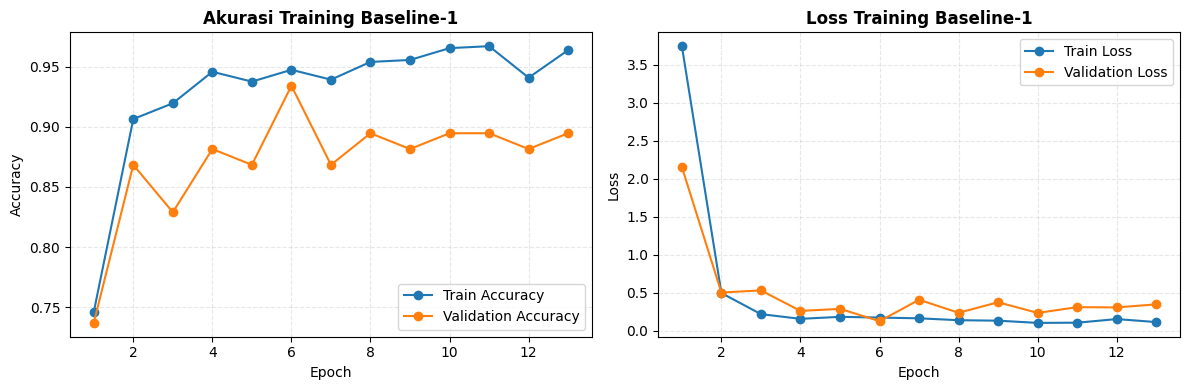

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step
Hasil evaluasi model pada data test:
Akurasi  : 0.9610
Precision: 0.9670
Recall   : 0.9667
F1-Score : 0.9667

Classification Report:
                                   precision    recall  f1-score   support

            Biru (Pavo Cristatus)     0.9655    0.9333    0.9492        30
             Hijau (Pavo Muticus)     0.9355    0.9667    0.9508        30
Ungu (Pavo Cristatus mut. purple)     1.0000    1.0000    1.0000        17

                         accuracy                         0.9610        77
                        macro avg     0.9670    0.9667    0.9667        77
                     weighted avg     0.9614    0.9610    0.9610        77



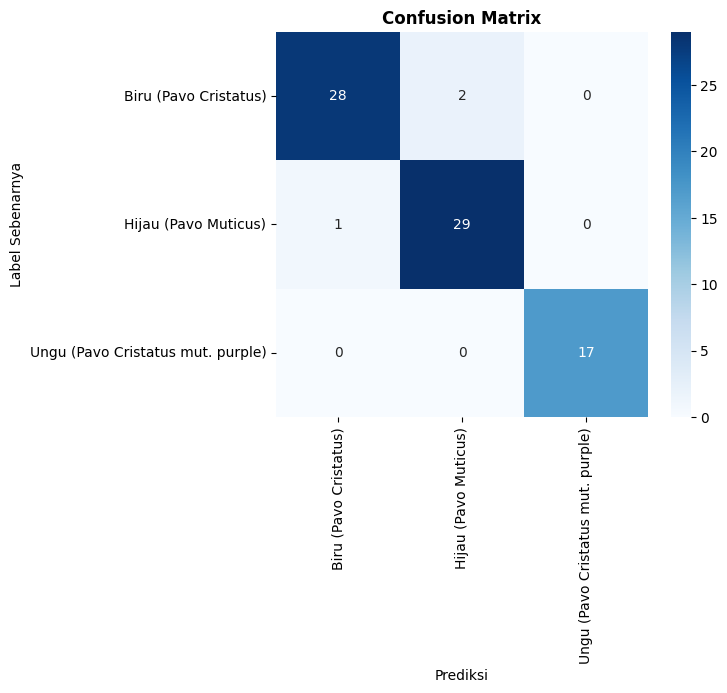

Evaluasi Baseline-1 selesai.


In [ ]:
# Visualisasi history training
plot_training_history(history_baseline_1, title_suffix="Baseline-1")

# Evaluasi model pada data test
baseline_1_metrics = evaluate_model(
    model=baseline_1_model,
    test_generator=test_generator,
    class_names=class_names
)

print("Evaluasi Baseline-1 selesai.")

## 9. Baseline-2: Two-Stage Partial Fine-Tuning

Stage 1: freeze total backbone, train head dulu
Stage 2: buka sebagian layer atas backbone, lalu fine-tuning dengan learning rate kecil

#### Build model Baseline-2 dan freeze backbone

In [ ]:
# Membangun model baseline
baseline_2_model, baseline_2_backbone = build_baseline_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes
)

# Membekukan seluruh backbone untuk stage 1
freeze_backbone(baseline_2_backbone)

# Menampilkan ringkasan model
baseline_2_model.summary()

# Cek ringkasan layer trainable
print("Baseline-2 berhasil dibuat untuk Stage 1.")
check_trainable_layers(baseline_2_model)

Model: "Baseline_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Baseline-2 berhasil dibuat untuk Stage 1.
Ringkasan layer model:
Jumlah total layer        : 179
Jumlah layer trainable    : 4
Jumlah layer non-trainable: 175


#### Compile dan callback Stage 1

In [ ]:
# Path penyimpanan model terbaik stage 1
baseline_2_stage1_model_path = str(DATASET_DIR.parent / "baseline_2_stage1_best.keras")

# Compile model untuk stage 1
baseline_2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 1
baseline_2_stage1_callbacks = get_callbacks(baseline_2_stage1_model_path)

print("Baseline-2 Stage 1 berhasil di-compile.")
print(f"Model terbaik Stage 1 akan disimpan di: {baseline_2_stage1_model_path}")

Baseline-2 Stage 1 berhasil di-compile.
Model terbaik Stage 1 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage1_best.keras


#### Training Stage 1

In [ ]:
steps_per_epoch_b2_stage1 = len(train_generator)

print(f"Steps per epoch Baseline-2 Stage 1: {steps_per_epoch_b2_stage1}")

history_baseline_2_stage1 = baseline_2_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    steps_per_epoch=steps_per_epoch_b2_stage1,
    callbacks=baseline_2_stage1_callbacks,
    verbose=1
)

Steps per epoch Baseline-2 Stage 1: 39
Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5967 - loss: 8.1759
Epoch 1: val_loss improved from None to 0.40435, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7623 - loss: 4.1963 - val_accuracy: 0.8947 - val_loss: 0.4043 - learning_rate: 0.0100
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8783 - loss: 0.5767
Epoch 2: val_loss improved from 0.40435 to 0.38167, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9049 - loss: 0.4091 - val_accuracy: 0.8947 - val_loss: 0.3817 - learning_rate: 0.0100
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1

#### Partial unfreeze dan compile Stage 2

In [ ]:
# Membuka sebagian layer backbone mulai dari blok atas
partial_unfreeze_backbone(baseline_2_backbone, unfreeze_from="conv5_block1")

# Cek ringkasan layer trainable setelah partial unfreeze
print("Baseline-2 masuk ke Stage 2 (partial fine-tuning).")
check_trainable_layers(baseline_2_model)

# Path penyimpanan model terbaik stage 2
baseline_2_stage2_model_path = str(DATASET_DIR.parent / "baseline_2_stage2_best.keras")

# Compile ulang model untuk stage 2 dengan learning rate lebih kecil
baseline_2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 2
baseline_2_stage2_callbacks = get_callbacks(baseline_2_stage2_model_path)

print("Baseline-2 Stage 2 berhasil di-compile.")
print(f"Model terbaik Stage 2 akan disimpan di: {baseline_2_stage2_model_path}")

Baseline-2 masuk ke Stage 2 (partial fine-tuning).
Ringkasan layer model:
Jumlah total layer        : 179
Jumlah layer trainable    : 36
Jumlah layer non-trainable: 143
Baseline-2 Stage 2 berhasil di-compile.
Model terbaik Stage 2 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage2_best.keras


#### Training Stage 2, plot, dan evaluasi

Steps per epoch Baseline-2 Stage 2: 39
Epoch 1/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8736 - loss: 0.3046
Epoch 1: val_loss improved from None to 0.50548, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage2_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.8951 - loss: 0.2479 - val_accuracy: 0.8553 - val_loss: 0.5055 - learning_rate: 1.0000e-05
Epoch 2/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9664 - loss: 0.1085
Epoch 2: val_loss did not improve from 0.50548
39/39 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9689 - loss: 0.1038 - val_accuracy: 0.8421 - val_loss: 0.6767 - learning_rate: 1.0000e-05
Epoch 3/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9654 - loss: 0.1031
Epoch 3: val_loss did not improve from 0.50548
39/39 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9639 - loss: 0.1092 - val_accuracy: 0.8553

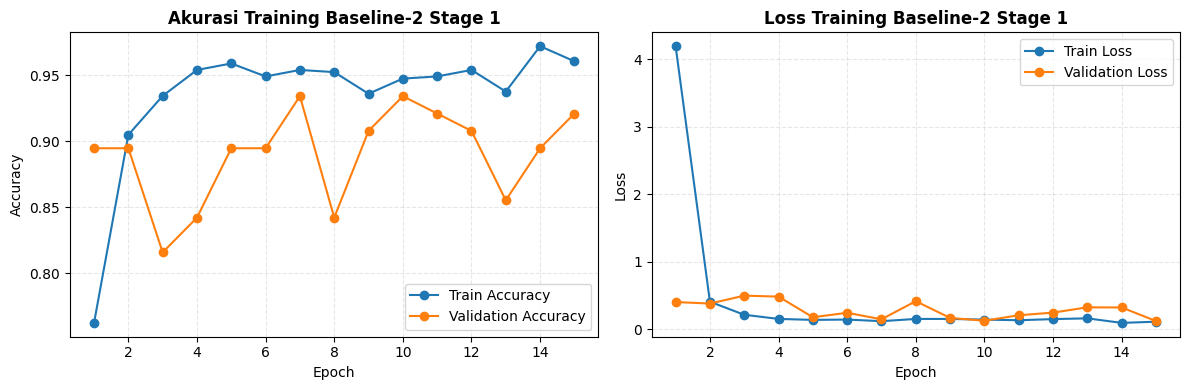

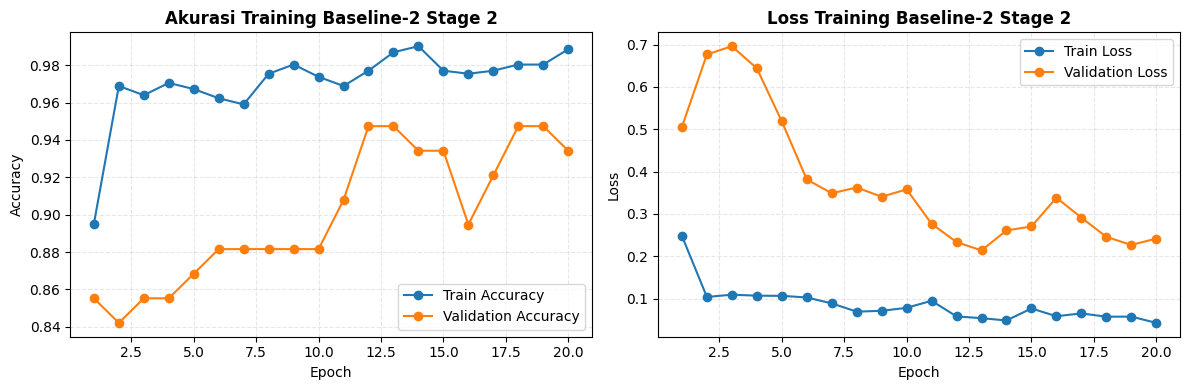

5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
Hasil evaluasi model pada data test:
Akurasi  : 0.9610
Precision: 0.9670
Recall   : 0.9667
F1-Score : 0.9667

Classification Report:
                                   precision    recall  f1-score   support

            Biru (Pavo Cristatus)     0.9355    0.9667    0.9508        30
             Hijau (Pavo Muticus)     0.9655    0.9333    0.9492        30
Ungu (Pavo Cristatus mut. purple)     1.0000    1.0000    1.0000        17

                         accuracy                         0.9610        77
                        macro avg     0.9670    0.9667    0.9667        77
                     weighted avg     0.9614    0.9610    0.9610        77



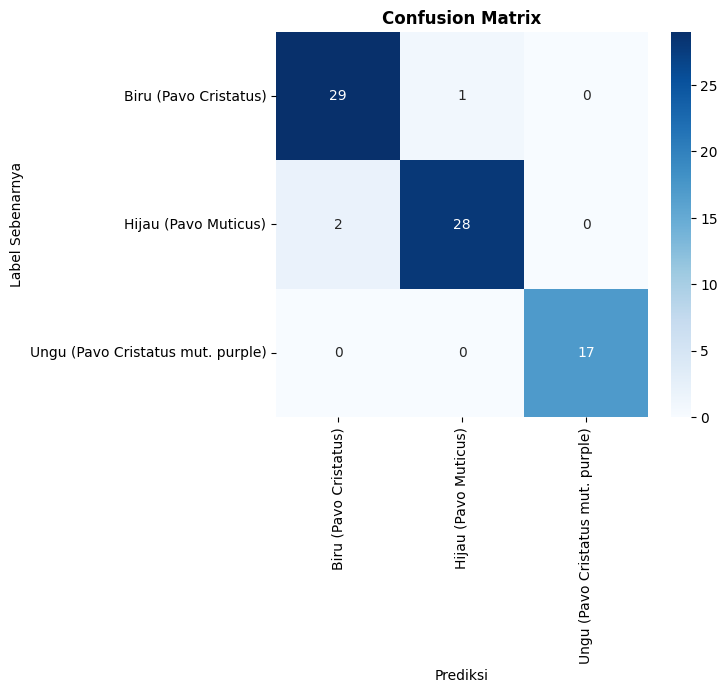

Evaluasi Baseline-2 selesai.


In [ ]:
steps_per_epoch_b2_stage2 = len(train_generator)

print(f"Steps per epoch Baseline-2 Stage 2: {steps_per_epoch_b2_stage2}")

history_baseline_2_stage2 = baseline_2_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    steps_per_epoch=steps_per_epoch_b2_stage2,
    callbacks=baseline_2_stage2_callbacks,
    verbose=1
)

# Visualisasi history training
plot_training_history(history_baseline_2_stage1, title_suffix="Baseline-2 Stage 1")
plot_training_history(history_baseline_2_stage2, title_suffix="Baseline-2 Stage 2")

# Evaluasi model pada data test
baseline_2_metrics = evaluate_model(
    model=baseline_2_model,
    test_generator=test_generator,
    class_names=class_names
)

print("Evaluasi Baseline-2 selesai.")

## Baseline-3: Two-Stage Full Fine-Tuning

Stage 1: freeze total backbone, train head
Stage 2: buka seluruh backbone, lalu fine-tuning dengan learning rate kecil

#### Build model Baseline-3 dan freeze backbone

In [ ]:
# Membangun model baseline
baseline_3_model, baseline_3_backbone = build_baseline_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes
)

# Membekukan seluruh backbone untuk stage 1
freeze_backbone(baseline_3_backbone)

# Menampilkan ringkasan model
baseline_3_model.summary()

# Cek ringkasan layer trainable
print("Baseline-3 berhasil dibuat untuk Stage 1.")
check_trainable_layers(baseline_3_model)

Model: "Baseline_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Baseline-3 berhasil dibuat untuk Stage 1.
Ringkasan layer model:
Jumlah total layer        : 179
Jumlah layer trainable    : 4
Jumlah layer non-trainable: 175


#### Compile dan callback Stage 1

In [ ]:
# Path penyimpanan model terbaik stage 1
baseline_3_stage1_model_path = str(DATASET_DIR.parent / "baseline_3_stage1_best.keras")

# Compile model untuk stage 1
baseline_3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 1
baseline_3_stage1_callbacks = get_callbacks(baseline_3_stage1_model_path)

print("Baseline-3 Stage 1 berhasil di-compile.")
print(f"Model terbaik Stage 1 akan disimpan di: {baseline_3_stage1_model_path}")

Baseline-3 Stage 1 berhasil di-compile.
Model terbaik Stage 1 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage1_best.keras


#### Training Stage 1

In [ ]:
steps_per_epoch_b3_stage1 = len(train_generator)

print(f"Steps per epoch Baseline-3 Stage 1: {steps_per_epoch_b3_stage1}")

history_baseline_3_stage1 = baseline_3_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    steps_per_epoch=steps_per_epoch_b3_stage1,
    callbacks=baseline_3_stage1_callbacks,
    verbose=1
)

Steps per epoch Baseline-3 Stage 1: 39
Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6062 - loss: 7.4167
Epoch 1: val_loss improved from None to 0.25135, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.7541 - loss: 3.4224 - val_accuracy: 0.9342 - val_loss: 0.2514 - learning_rate: 0.0100
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9368 - loss: 0.2283
Epoch 2: val_loss did not improve from 0.25135
39/39 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9311 - loss: 0.2493 - val_accuracy: 0.8684 - val_loss: 0.3527 - learning_rate: 0.0100
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8835 - loss: 0.3732
Epoch 3: val_loss did not improve from 0.25135
39/39 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9213 - loss: 0.2320 - val_accuracy: 0.8421 - val_lo

#### Full unfreeze dan compile Stage 2

In [ ]:
# Membuka seluruh layer backbone
full_unfreeze_backbone(baseline_3_backbone)

# Cek ringkasan layer trainable setelah full unfreeze
print("Baseline-3 masuk ke Stage 2 (full fine-tuning).")
check_trainable_layers(baseline_3_model)

# Path penyimpanan model terbaik stage 2
baseline_3_stage2_model_path = str(DATASET_DIR.parent / "baseline_3_stage2_best.keras")

# Compile ulang model untuk stage 2 dengan learning rate lebih kecil
baseline_3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 2
baseline_3_stage2_callbacks = get_callbacks(baseline_3_stage2_model_path)

print("Baseline-3 Stage 2 berhasil di-compile.")
print(f"Model terbaik Stage 2 akan disimpan di: {baseline_3_stage2_model_path}")

Baseline-3 masuk ke Stage 2 (full fine-tuning).
Ringkasan layer model:
Jumlah total layer        : 179
Jumlah layer trainable    : 179
Jumlah layer non-trainable: 0
Baseline-3 Stage 2 berhasil di-compile.
Model terbaik Stage 2 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage2_best.keras


#### Training Stage 2, plot, dan evaluasi

Steps per epoch Baseline-3 Stage 2: 39
Epoch 1/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7878 - loss: 0.5873
Epoch 1: val_loss improved from None to 0.43280, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage2_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.8262 - loss: 0.4723 - val_accuracy: 0.8553 - val_loss: 0.4328 - learning_rate: 1.0000e-05
Epoch 2/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9384 - loss: 0.1702
Epoch 2: val_loss did not improve from 0.43280
39/39 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9443 - loss: 0.1605 - val_accuracy: 0.8553 - val_loss: 0.4593 - learning_rate: 1.0000e-05
Epoch 3/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9609 - loss: 0.1024
Epoch 3: val_loss improved from 0.43280 to 0.33127, saving model to /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage2_best.keras

Epoch

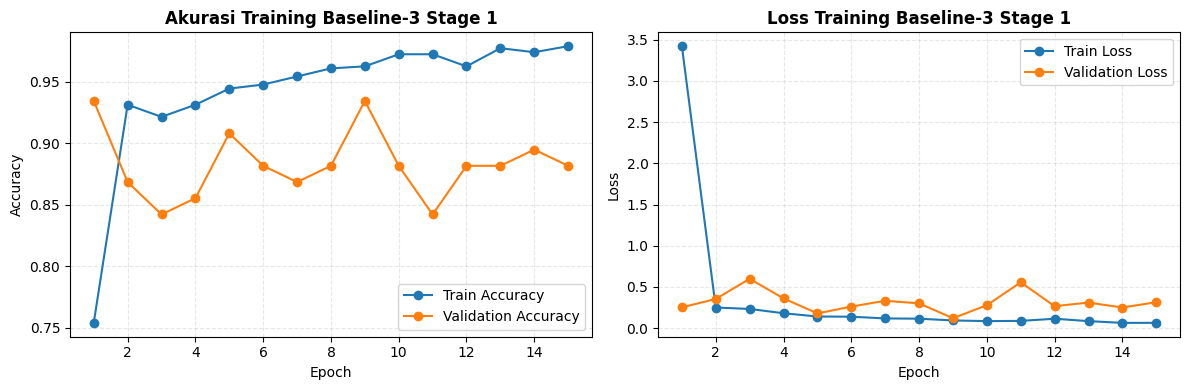

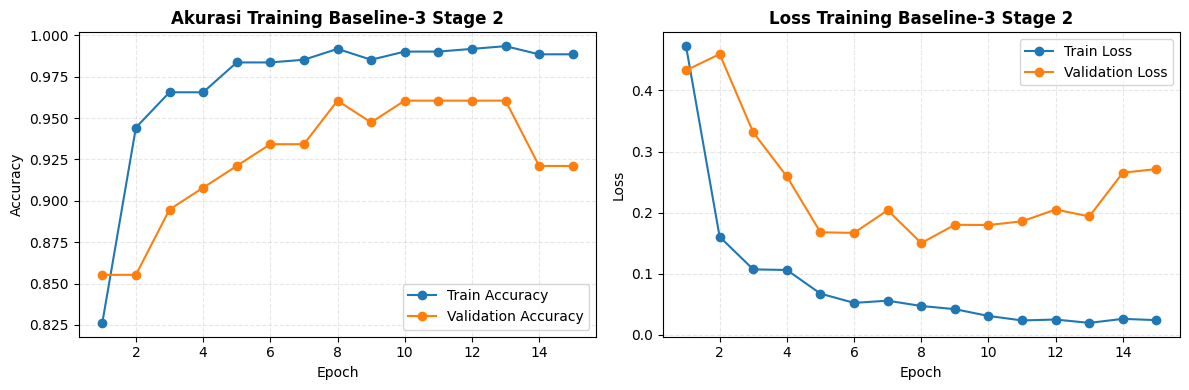

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Hasil evaluasi model pada data test:
Akurasi  : 0.9740
Precision: 0.9778
Recall   : 0.9778
F1-Score : 0.9778

Classification Report:
                                   precision    recall  f1-score   support

            Biru (Pavo Cristatus)     0.9667    0.9667    0.9667        30
             Hijau (Pavo Muticus)     0.9667    0.9667    0.9667        30
Ungu (Pavo Cristatus mut. purple)     1.0000    1.0000    1.0000        17

                         accuracy                         0.9740        77
                        macro avg     0.9778    0.9778    0.9778        77
                     weighted avg     0.9740    0.9740    0.9740        77



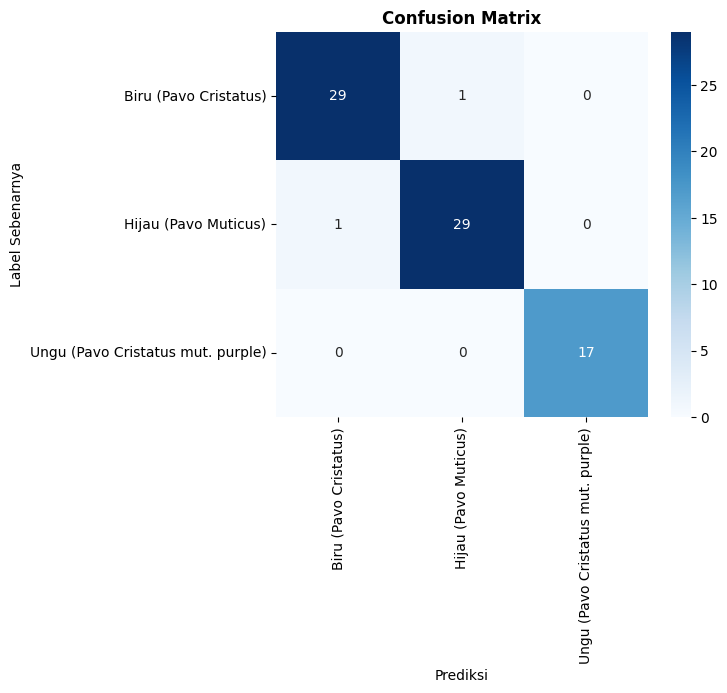

Evaluasi Baseline-3 selesai.


In [ ]:
steps_per_epoch_b3_stage2 = len(train_generator)

print(f"Steps per epoch Baseline-3 Stage 2: {steps_per_epoch_b3_stage2}")

history_baseline_3_stage2 = baseline_3_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    steps_per_epoch=steps_per_epoch_b3_stage2,
    callbacks=baseline_3_stage2_callbacks,
    verbose=1
)

# Visualisasi history training
plot_training_history(history_baseline_3_stage1, title_suffix="Baseline-3 Stage 1")
plot_training_history(history_baseline_3_stage2, title_suffix="Baseline-3 Stage 2")

# Evaluasi model pada data test
baseline_3_metrics = evaluate_model(
    model=baseline_3_model,
    test_generator=test_generator,
    class_names=class_names
)

print("Evaluasi Baseline-3 selesai.")

## 11. Rekap Baseline

#### Rekap metrik 3 baseline

In [ ]:
# Fungsi bantu untuk mengambil nilai terbaik validation dari history
def get_best_val_metrics(history):
    val_loss = history.history.get("val_loss", [])
    val_acc = history.history.get("val_accuracy", [])

    if len(val_loss) == 0 or len(val_acc) == 0:
        return None, None, None

    best_epoch = int(np.argmin(val_loss)) + 1
    best_val_loss = float(np.min(val_loss))
    best_val_acc = float(val_acc[best_epoch - 1])

    return best_epoch, best_val_loss, best_val_acc

# Ambil metrik validation terbaik
b1_best_epoch, b1_best_val_loss, b1_best_val_acc = get_best_val_metrics(history_baseline_1)
b2_best_epoch, b2_best_val_loss, b2_best_val_acc = get_best_val_metrics(history_baseline_2_stage2)
b3_best_epoch, b3_best_val_loss, b3_best_val_acc = get_best_val_metrics(history_baseline_3_stage2)

# Buat tabel rekap
baseline_results_df = pd.DataFrame([
    {
        "Skenario": "Baseline-1",
        "Strategi": "Freeze Total",
        "Best Epoch": b1_best_epoch,
        "Best Val Loss": round(b1_best_val_loss, 4) if b1_best_val_loss is not None else None,
        "Best Val Accuracy": round(b1_best_val_acc, 4) if b1_best_val_acc is not None else None,
        "Test Accuracy": round(baseline_1_metrics["accuracy"], 4),
        "Precision Macro": round(baseline_1_metrics["precision_macro"], 4),
        "Recall Macro": round(baseline_1_metrics["recall_macro"], 4),
        "F1 Macro": round(baseline_1_metrics["f1_macro"], 4)
    },
    {
        "Skenario": "Baseline-2",
        "Strategi": "Partial Fine-Tuning",
        "Best Epoch": b2_best_epoch,
        "Best Val Loss": round(b2_best_val_loss, 4) if b2_best_val_loss is not None else None,
        "Best Val Accuracy": round(b2_best_val_acc, 4) if b2_best_val_acc is not None else None,
        "Test Accuracy": round(baseline_2_metrics["accuracy"], 4),
        "Precision Macro": round(baseline_2_metrics["precision_macro"], 4),
        "Recall Macro": round(baseline_2_metrics["recall_macro"], 4),
        "F1 Macro": round(baseline_2_metrics["f1_macro"], 4)
    },
    {
        "Skenario": "Baseline-3",
        "Strategi": "Full Fine-Tuning",
        "Best Epoch": b3_best_epoch,
        "Best Val Loss": round(b3_best_val_loss, 4) if b3_best_val_loss is not None else None,
        "Best Val Accuracy": round(b3_best_val_acc, 4) if b3_best_val_acc is not None else None,
        "Test Accuracy": round(baseline_3_metrics["accuracy"], 4),
        "Precision Macro": round(baseline_3_metrics["precision_macro"], 4),
        "Recall Macro": round(baseline_3_metrics["recall_macro"], 4),
        "F1 Macro": round(baseline_3_metrics["f1_macro"], 4)
    }
])

print("Rekap hasil eksperimen baseline:")
display(baseline_results_df)

Rekap hasil eksperimen baseline:


,Skenario,Strategi,Best Epoch,Best Val Loss,Best Val Accuracy,Test Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Baseline-1,Freeze Total,6,0.1238,0.9342,0.961,0.9670,0.9667,0.9667
1,Baseline-2,Partial Fine-Tuning,13,0.2137,0.9474,0.961,0.9670,0.9667,0.9667
2,Baseline-3,Full Fine-Tuning,8,0.1503,0.9605,0.974,0.9778,0.9778,0.9778


#### Visualisasi perbandingan baseline

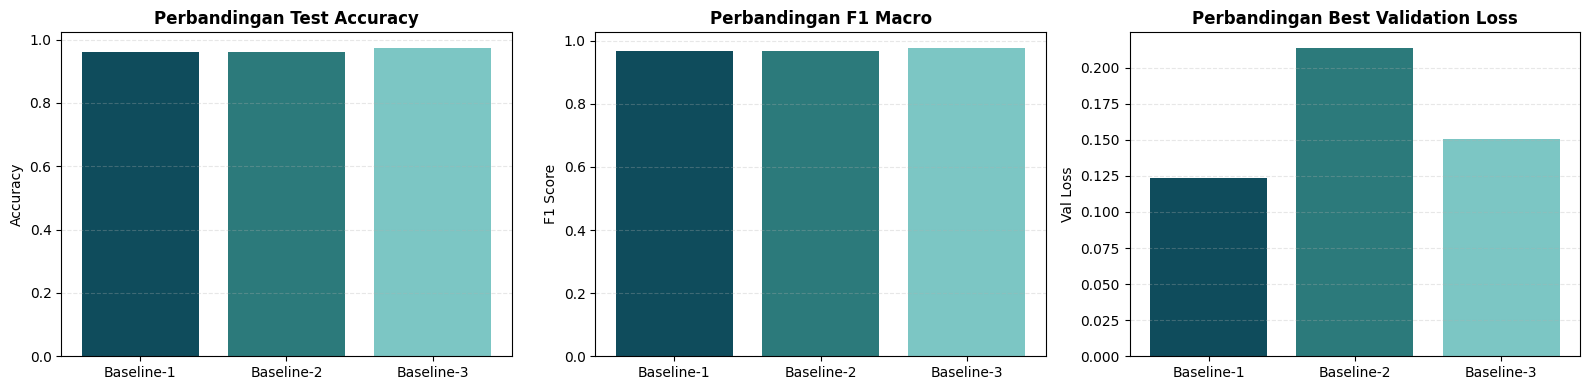

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Palet warna satu tone
colors = ["#0F4C5C", "#2C7A7B", "#7CC6C4"]

# Grafik Test Accuracy
axes[0].bar(baseline_results_df["Skenario"], baseline_results_df["Test Accuracy"], color=colors)
axes[0].set_title("Perbandingan Test Accuracy", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# Grafik F1 Macro
axes[1].bar(baseline_results_df["Skenario"], baseline_results_df["F1 Macro"], color=colors)
axes[1].set_title("Perbandingan F1 Macro", fontweight="bold")
axes[1].set_ylabel("F1 Score")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

# Grafik Best Validation Loss
axes[2].bar(baseline_results_df["Skenario"], baseline_results_df["Best Val Loss"], color=colors)
axes[2].set_title("Perbandingan Best Validation Loss", fontweight="bold")
axes[2].set_ylabel("Val Loss")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Builder Model SK

#### Helper conv branch untuk SK

In [ ]:
def conv_bn_relu(x, filters, kernel_size, name_prefix):
    """
    Blok helper: Conv2D + BatchNormalization + ReLU

    Parameter:
    - x          : input tensor
    - filters    : jumlah filter output
    - kernel_size: ukuran kernel
    - name_prefix: prefix nama layer

    Return:
    - output tensor
    """

    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        name=f"{name_prefix}_conv"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{name_prefix}_bn"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{name_prefix}_relu"
    )(x)

    return x

print("Fungsi conv_bn_relu() berhasil dibuat.")

Fungsi conv_bn_relu() berhasil dibuat.


#### Fungsi Selective Kernel Block

In [ ]:
@tf.keras.utils.register_keras_serializable()
class StackLayer(tf.keras.layers.Layer):
    """
    Custom layer untuk melakukan stack tensor
    pada dimensi terakhir.
    """

    def call(self, inputs):
        return tf.stack(inputs, axis=-1)


@tf.keras.utils.register_keras_serializable()
class SliceLayer(tf.keras.layers.Layer):
    """
    Custom layer untuk mengambil slice tensor
    pada index tertentu di dimensi terakhir.
    """

    def __init__(self, index, **kwargs):
        super(SliceLayer, self).__init__(**kwargs)
        self.index = index

    def call(self, inputs):
        return inputs[..., self.index]

    def get_config(self):
        config = super().get_config()
        config.update({
            "index": self.index
        })
        return config


def selective_kernel_block(inputs, filters, reduction=16, name_prefix="sk"):
    """
    Selective Kernel Block dengan 2 branch:
    - Branch A: Conv 3x3
    - Branch B: Conv 5x5

    Mekanisme:
    Split -> Fuse -> Select

    Parameter:
    - inputs     : input tensor
    - filters    : jumlah filter output
    - reduction  : reduction ratio untuk bottleneck attention
    - name_prefix: prefix nama layer

    Return:
    - output tensor hasil weighted fusion
    """

    # ---------------------------------------------------
    # Split: dua branch konvolusi
    branch_3x3 = conv_bn_relu(
        inputs,
        filters=filters,
        kernel_size=(3, 3),
        name_prefix=f"{name_prefix}_branch3x3"
    )

    branch_5x5 = conv_bn_relu(
        inputs,
        filters=filters,
        kernel_size=(5, 5),
        name_prefix=f"{name_prefix}_branch5x5"
    )

    # ---------------------------------------------------
    # Fuse: gabungkan konteks global
    fused = tf.keras.layers.Add(
        name=f"{name_prefix}_fuse_add"
    )([branch_3x3, branch_5x5])

    gap = tf.keras.layers.GlobalAveragePooling2D(
        name=f"{name_prefix}_gap"
    )(fused)

    reduced_filters = max(filters // reduction, 8)

    z = tf.keras.layers.Dense(
        reduced_filters,
        activation="relu",
        name=f"{name_prefix}_fc_reduction"
    )(gap)

    # ---------------------------------------------------
    # Select: attention per channel
    attention_3x3 = tf.keras.layers.Dense(
        filters,
        name=f"{name_prefix}_fc_attn_3x3"
    )(z)

    attention_5x5 = tf.keras.layers.Dense(
        filters,
        name=f"{name_prefix}_fc_attn_5x5"
    )(z)

    # ---------------------------------------------------
    # Stack attention logits menjadi
    # shape: (batch, filters, 2)
    attention_stack = StackLayer(
        name=f"{name_prefix}_attn_stack"
    )([attention_3x3, attention_5x5])

    # ---------------------------------------------------
    # Softmax antar branch
    attention_softmax = tf.keras.layers.Softmax(
        axis=-1,
        name=f"{name_prefix}_attn_softmax"
    )(attention_stack)

    # ---------------------------------------------------
    # Ambil bobot masing-masing branch
    weight_3x3 = SliceLayer(
        index=0,
        name=f"{name_prefix}_weight_3x3"
    )(attention_softmax)

    weight_5x5 = SliceLayer(
        index=1,
        name=f"{name_prefix}_weight_5x5"
    )(attention_softmax)

    # ---------------------------------------------------
    # Reshape menjadi
    # (batch, 1, 1, filters)
    weight_3x3 = tf.keras.layers.Reshape(
        (1, 1, filters),
        name=f"{name_prefix}_reshape_3x3"
    )(weight_3x3)

    weight_5x5 = tf.keras.layers.Reshape(
        (1, 1, filters),
        name=f"{name_prefix}_reshape_5x5"
    )(weight_5x5)

    # ---------------------------------------------------
    # Weighted fusion
    scaled_3x3 = tf.keras.layers.Multiply(
        name=f"{name_prefix}_scale_3x3"
    )([branch_3x3, weight_3x3])

    scaled_5x5 = tf.keras.layers.Multiply(
        name=f"{name_prefix}_scale_5x5"
    )([branch_5x5, weight_5x5])

    output = tf.keras.layers.Add(
        name=f"{name_prefix}_output"
    )([scaled_3x3, scaled_5x5])

    return output


print("Fungsi selective_kernel_block() berhasil dibuat.")

Fungsi selective_kernel_block() berhasil dibuat.


#### Builder model ResNet50 + SK

In [ ]:
def build_sk_model(input_shape=(224, 224, 3), num_classes=3, reduction=16):
    """
    Membangun model usulan ResNet50 + SK dengan strategi
    multi-stage feature refinement + fusion.

    Feature map yang digunakan:
    - Conv2_x akhir  -> conv2_block3_out
    - Conv3_x akhir  -> conv3_block4_out
    - Conv4_x akhir  -> conv4_block6_out

    Alur:
    backbone pretrained -> ambil feature map 3 stage ->
    SK block per stage -> GAP per stage -> concatenate ->
    Dense 256 -> Dropout 0.3 -> Softmax

    Return:
    - model    : model akhir ResNet50 + SK
    - backbone : backbone ResNet50 pretrained
    """

    # Backbone ResNet50 pretrained ImageNet
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Ambil output akhir tiap stage representatif
    feat_conv2 = backbone.get_layer("conv2_block3_out").output
    feat_conv3 = backbone.get_layer("conv3_block4_out").output
    feat_conv4 = backbone.get_layer("conv4_block6_out").output

    # SK block pada tiap stage
    sk_conv2 = selective_kernel_block(
        feat_conv2,
        filters=int(feat_conv2.shape[-1]),
        reduction=reduction,
        name_prefix="sk_conv2"
    )

    sk_conv3 = selective_kernel_block(
        feat_conv3,
        filters=int(feat_conv3.shape[-1]),
        reduction=reduction,
        name_prefix="sk_conv3"
    )

    sk_conv4 = selective_kernel_block(
        feat_conv4,
        filters=int(feat_conv4.shape[-1]),
        reduction=reduction,
        name_prefix="sk_conv4"
    )

    # Global pooling per stage
    gap_conv2 = tf.keras.layers.GlobalAveragePooling2D(name="gap_sk_conv2")(sk_conv2)
    gap_conv3 = tf.keras.layers.GlobalAveragePooling2D(name="gap_sk_conv3")(sk_conv3)
    gap_conv4 = tf.keras.layers.GlobalAveragePooling2D(name="gap_sk_conv4")(sk_conv4)

    # Fusion antar-stage
    fused_features = tf.keras.layers.Concatenate(name="sk_feature_fusion")(
        [gap_conv2, gap_conv3, gap_conv4]
    )

    # Head classifier (sama dengan baseline)
    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        name="sk_dense_256"
    )(fused_features)

    x = tf.keras.layers.Dropout(
        0.3,
        name="sk_dropout_03"
    )(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="sk_output_layer"
    )(x)

    # Model akhir
    model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=outputs,
        name="ResNet50_SK"
    )

    return model, backbone

print("Fungsi build_sk_model() berhasil dibuat.")

Fungsi build_sk_model() berhasil dibuat.


#### Helper freeze/unfreeze khusus model SK

In [ ]:
def freeze_sk_backbone(backbone):
    """
    Membekukan seluruh layer backbone pretrained.
    Layer SK block dan head tetap trainable karena
    tidak termasuk di dalam backbone.
    """
    for layer in backbone.layers:
        layer.trainable = False


def partial_unfreeze_sk_backbone(backbone, unfreeze_from="conv4_block1"):
    """
    Membuka sebagian layer backbone mulai dari layer tertentu.

    Catatan:
    Karena model SK menggunakan feature map sampai Conv4_x,
    maka partial fine-tuning paling masuk akal dimulai dari conv4_block1.
    """
    set_trainable = False

    for layer in backbone.layers:
        if unfreeze_from in layer.name:
            set_trainable = True

        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False


def full_unfreeze_sk_backbone(backbone):
    """
    Membuka seluruh layer backbone pretrained.
    """
    for layer in backbone.layers:
        layer.trainable = True


def check_trainable_layers_sk(model, backbone):
    """
    Menampilkan ringkasan trainable layer untuk:
    - backbone pretrained
    - layer non-backbone (SK block + head)
    """
    backbone_layer_names = set(layer.name for layer in backbone.layers)

    backbone_trainable = 0
    backbone_non_trainable = 0
    extra_trainable = 0
    extra_non_trainable = 0

    for layer in model.layers:
        if layer.name in backbone_layer_names:
            if layer.trainable:
                backbone_trainable += 1
            else:
                backbone_non_trainable += 1
        else:
            if layer.trainable:
                extra_trainable += 1
            else:
                extra_non_trainable += 1

    print("Ringkasan trainable layer model SK:")
    print(f"Total layer model                 : {len(model.layers)}")
    print("-" * 50)
    print(f"Backbone trainable               : {backbone_trainable}")
    print(f"Backbone non-trainable           : {backbone_non_trainable}")
    print(f"SK block + head trainable        : {extra_trainable}")
    print(f"SK block + head non-trainable    : {extra_non_trainable}")

print("Fungsi freeze/unfreeze khusus model SK berhasil dibuat.")

Fungsi freeze/unfreeze khusus model SK berhasil dibuat.


## 13. SK-1

#### Build model SK dan freeze backbone

In [ ]:
# Membangun model ResNet50 + SK
sk_1_model, sk_1_backbone = build_sk_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes,
    reduction=16
)

# Membekukan seluruh backbone pretrained
freeze_sk_backbone(sk_1_backbone)

# Menampilkan ringkasan model
sk_1_model.summary()

# Cek ringkasan layer trainable
print("SK-1 berhasil dibuat.")
check_trainable_layers_sk(sk_1_model, sk_1_backbone)

Model: "ResNet50_SK"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 56,117,747 (214.07 MB)

 Trainable params: 47,521,395 (181.28 MB)

 Non-trainable params: 8,596,352 (32.79 MB)

SK-1 berhasil dibuat.
Ringkasan trainable layer model SK:
Total layer model                 : 210
--------------------------------------------------
Backbone trainable               : 0
Backbone non-trainable           : 143
SK block + head trainable        : 67
SK block + head non-trainable    : 0


#### Compile model dan callback

In [ ]:
# Path penyimpanan model terbaik SK-1
sk_1_model_path = str(DATASET_DIR.parent / "sk_1_best.keras")

# Compile model
sk_1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback training
sk_1_callbacks = get_callbacks(sk_1_model_path)

print("Model SK-1 berhasil di-compile.")
print(f"Model terbaik akan disimpan di: {sk_1_model_path}")

Model SK-1 berhasil di-compile.
Model terbaik akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/sk_1_best.keras


#### Training SK-1

In [ ]:
steps_per_epoch_sk1 = len(train_generator)

print(f"Steps per epoch SK-1: {steps_per_epoch_sk1}")

history_sk_1 = sk_1_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=steps_per_epoch_sk1,
    callbacks=sk_1_callbacks,
    verbose=1
)

Steps per epoch SK-1: 39
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5295 - loss: 8.3237
Epoch 1: val_loss improved from None to 0.16514, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.7016 - loss: 3.1427 - val_accuracy: 0.9474 - val_loss: 0.1651 - learning_rate: 0.0100
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9072 - loss: 0.3020
Epoch 2: val_loss did not improve from 0.16514
39/39 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9361 - loss: 0.2170 - val_accuracy: 0.9211 - val_loss: 0.2433 - learning_rate: 0.0100
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9693 - loss: 0.0891
Epoch 3: val_loss did not improve from 0.16514
39/39 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9590 - loss: 0.1203 - val_accuracy: 0.9342 - val_loss: 0.2143 - learning_rate: 0.0100
Epoc

#### Plot history dan evaluasi SK-1

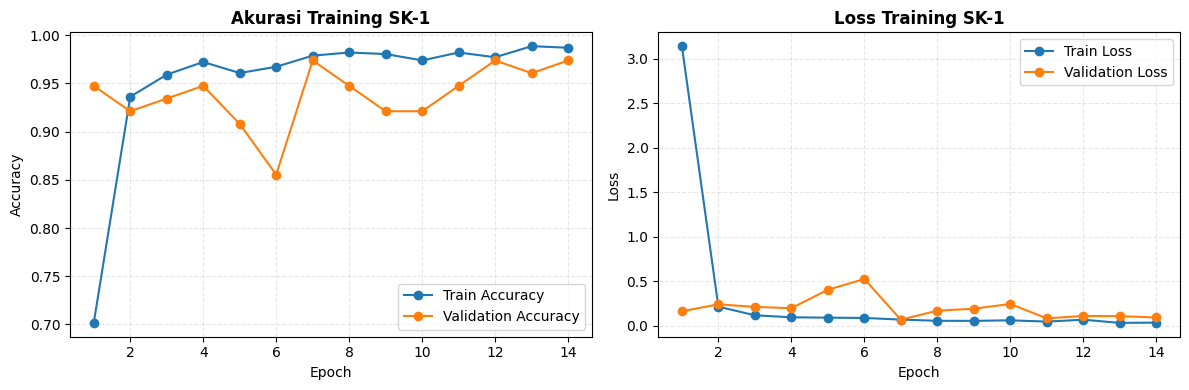

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step
Hasil evaluasi model pada data test:
Akurasi  : 0.9740
Precision: 0.9778
Recall   : 0.9778
F1-Score : 0.9778

Classification Report:
                                   precision    recall  f1-score   support

            Biru (Pavo Cristatus)     0.9667    0.9667    0.9667        30
             Hijau (Pavo Muticus)     0.9667    0.9667    0.9667        30
Ungu (Pavo Cristatus mut. purple)     1.0000    1.0000    1.0000        17

                         accuracy                         0.9740        77
                        macro avg     0.9778    0.9778    0.9778        77
                     weighted avg     0.9740    0.9740    0.9740        77



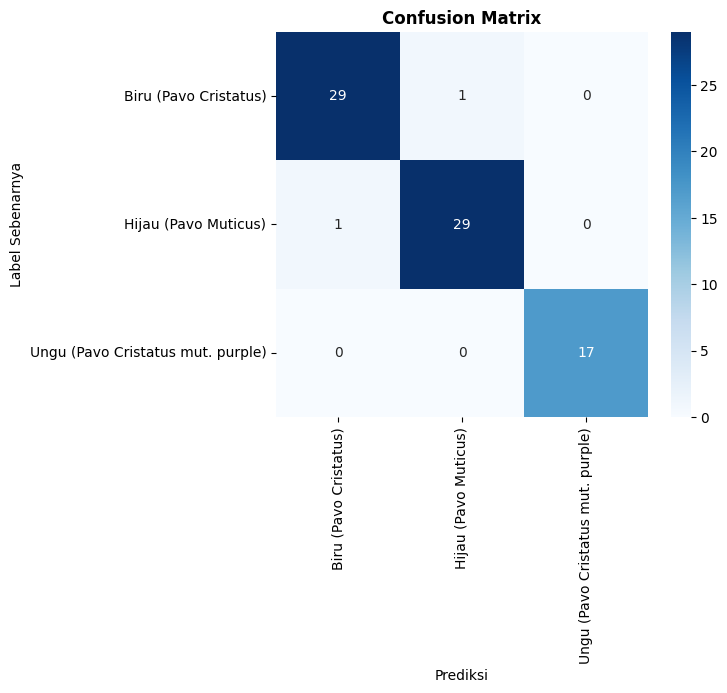

Evaluasi SK-1 selesai.


In [ ]:
# ============================================
# SK-1: visualisasi dan evaluasi
# ============================================

# Visualisasi history training
plot_training_history(history_sk_1, title_suffix="SK-1")

# Evaluasi model pada data test
sk_1_metrics = evaluate_model(
    model=sk_1_model,
    test_generator=test_generator,
    class_names=class_names
)

print("Evaluasi SK-1 selesai.")

## 14. SK-2

#### Build model SK dan freeze backbone

In [ ]:
# Membangun model ResNet50 + SK
sk_2_model, sk_2_backbone = build_sk_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes,
    reduction=16
)

# Membekukan seluruh backbone pretrained untuk stage 1
freeze_sk_backbone(sk_2_backbone)

# Menampilkan ringkasan model
sk_2_model.summary()

# Cek ringkasan layer trainable
print("SK-2 berhasil dibuat untuk Stage 1.")
check_trainable_layers_sk(sk_2_model, sk_2_backbone)

Model: "ResNet50_SK"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 56,117,747 (214.07 MB)

 Trainable params: 47,521,395 (181.28 MB)

 Non-trainable params: 8,596,352 (32.79 MB)

SK-2 berhasil dibuat untuk Stage 1.
Ringkasan trainable layer model SK:
Total layer model                 : 210
--------------------------------------------------
Backbone trainable               : 0
Backbone non-trainable           : 143
SK block + head trainable        : 67
SK block + head non-trainable    : 0


#### Compile dan callback Stage 1

In [ ]:
# Path penyimpanan model terbaik stage 1
sk_2_stage1_model_path = str(DATASET_DIR.parent / "sk_2_stage1_best.keras")

# Compile model untuk stage 1
sk_2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 1
sk_2_stage1_callbacks = get_callbacks(sk_2_stage1_model_path)

print("SK-2 Stage 1 berhasil di-compile.")
print(f"Model terbaik Stage 1 akan disimpan di: {sk_2_stage1_model_path}")

SK-2 Stage 1 berhasil di-compile.
Model terbaik Stage 1 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/sk_2_stage1_best.keras


#### Training Stage 1

In [ ]:
steps_per_epoch_sk2_stage1 = len(train_generator)

print(f"Steps per epoch SK-2 Stage 1: {steps_per_epoch_sk2_stage1}")

history_sk_2_stage1 = sk_2_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    steps_per_epoch=steps_per_epoch_sk2_stage1,
    callbacks=sk_2_stage1_callbacks,
    verbose=1
)

Steps per epoch SK-2 Stage 1: 39
Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5658 - loss: 6.6082
Epoch 1: val_loss improved from None to 3.84444, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_2_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_2_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.7279 - loss: 2.9508 - val_accuracy: 0.7895 - val_loss: 3.8444 - learning_rate: 0.0100
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8887 - loss: 0.4447
Epoch 2: val_loss improved from 3.84444 to 0.48146, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_2_stage1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_2_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.9180 - loss: 0.2867 - val_accuracy: 0.9079 - val_loss: 0.4815 - learning_rate: 0.0100
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9597 - 

#### Partial unfreeze backbone dan compile Stage 2

In [ ]:
# Membuka sebagian layer backbone mulai dari conv4_block1
partial_unfreeze_sk_backbone(sk_2_backbone, unfreeze_from="conv4_block1")

# Cek ringkasan layer trainable setelah partial unfreeze
print("SK-2 masuk ke Stage 2 (partial fine-tuning).")
check_trainable_layers_sk(sk_2_model, sk_2_backbone)

# Path penyimpanan model terbaik stage 2
sk_2_stage2_model_path = str(DATASET_DIR.parent / "sk_2_stage2_best.keras")

# Compile ulang model untuk stage 2 dengan learning rate lebih kecil
sk_2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 2
sk_2_stage2_callbacks = get_callbacks(sk_2_stage2_model_path)

print("SK-2 Stage 2 berhasil di-compile.")
print(f"Model terbaik Stage 2 akan disimpan di: {sk_2_stage2_model_path}")

SK-2 masuk ke Stage 2 (partial fine-tuning).
Ringkasan trainable layer model SK:
Total layer model                 : 210
--------------------------------------------------
Backbone trainable               : 62
Backbone non-trainable           : 81
SK block + head trainable        : 67
SK block + head non-trainable    : 0
SK-2 Stage 2 berhasil di-compile.
Model terbaik Stage 2 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/sk_2_stage2_best.keras


#### Training Stage 2, plot, dan evaluasi

Steps per epoch SK-2 Stage 2: 39
Epoch 1/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9701 - loss: 0.0850
Epoch 1: val_loss improved from None to 0.11329, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_2_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_2_stage2_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.9705 - loss: 0.0924 - val_accuracy: 0.9605 - val_loss: 0.1133 - learning_rate: 1.0000e-05
Epoch 2/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9689 - loss: 0.0898
Epoch 2: val_loss did not improve from 0.11329
39/39 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9721 - loss: 0.0899 - val_accuracy: 0.9342 - val_loss: 0.2016 - learning_rate: 1.0000e-05
Epoch 3/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9751 - loss: 0.0750
Epoch 3: val_loss did not improve from 0.11329
39/39 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9770 - loss: 0.0674 - val_accuracy: 0.9079 - val_loss: 0.263

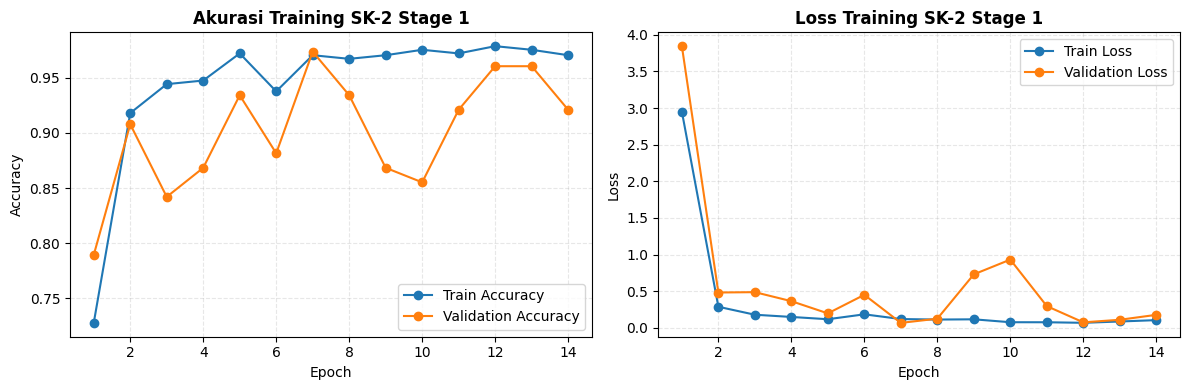

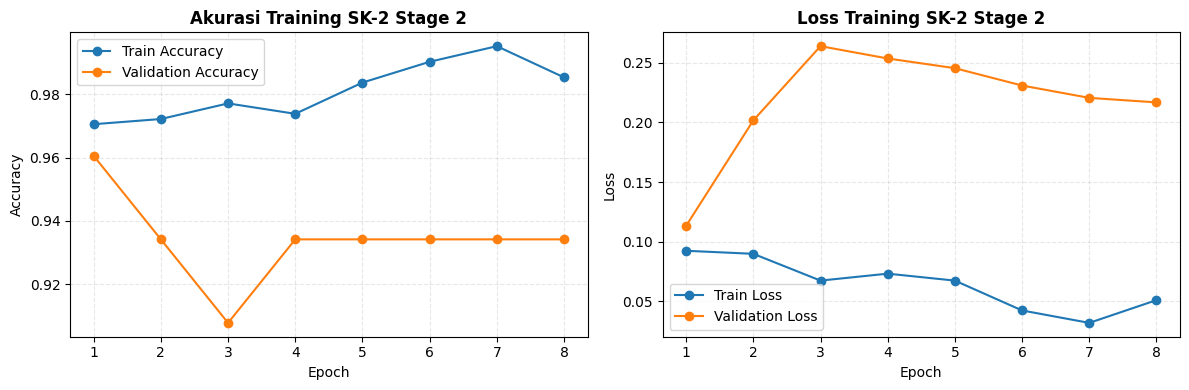

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Hasil evaluasi model pada data test:
Akurasi  : 0.9870
Precision: 0.9892
Recall   : 0.9889
F1-Score : 0.9889

Classification Report:
                                   precision    recall  f1-score   support

            Biru (Pavo Cristatus)     0.9677    1.0000    0.9836        30
             Hijau (Pavo Muticus)     1.0000    0.9667    0.9831        30
Ungu (Pavo Cristatus mut. purple)     1.0000    1.0000    1.0000        17

                         accuracy                         0.9870        77
                        macro avg     0.9892    0.9889    0.9889        77
                     weighted avg     0.9874    0.9870    0.9870        77



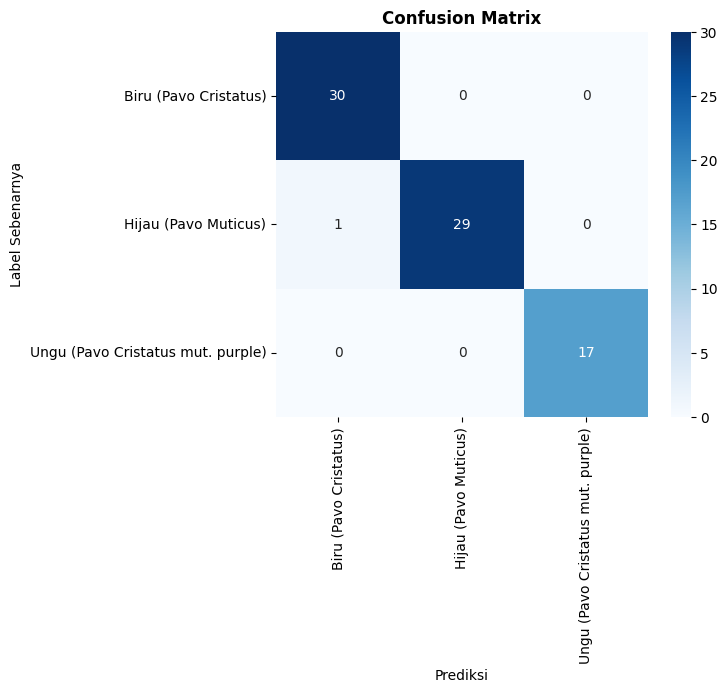

Evaluasi SK-2 selesai.


In [ ]:
steps_per_epoch_sk2_stage2 = len(train_generator)

print(f"Steps per epoch SK-2 Stage 2: {steps_per_epoch_sk2_stage2}")

history_sk_2_stage2 = sk_2_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    steps_per_epoch=steps_per_epoch_sk2_stage2,
    callbacks=sk_2_stage2_callbacks,
    verbose=1
)

# Visualisasi history training
plot_training_history(history_sk_2_stage1, title_suffix="SK-2 Stage 1")
plot_training_history(history_sk_2_stage2, title_suffix="SK-2 Stage 2")

# Evaluasi model pada data test
sk_2_metrics = evaluate_model(
    model=sk_2_model,
    test_generator=test_generator,
    class_names=class_names
)

print("Evaluasi SK-2 selesai.")

## 15. SK-3: Two-Stage Full Fine-Tuning

Stage 1: freeze total backbone pretrained, train SK block + head
Stage 2: full unfreeze backbone pretrained, fine-tuning dengan learning rate kecil
SK block dan head tetap trainable

#### Build model SK dan freeze backbone

In [ ]:
# Membangun model ResNet50 + SK
sk_3_model, sk_3_backbone = build_sk_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes,
    reduction=16
)

# Membekukan seluruh backbone pretrained untuk stage 1
freeze_sk_backbone(sk_3_backbone)

# Menampilkan ringkasan model
sk_3_model.summary()

# Cek ringkasan layer trainable
print("SK-3 berhasil dibuat untuk Stage 1.")
check_trainable_layers_sk(sk_3_model, sk_3_backbone)

Model: "ResNet50_SK"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 56,117,747 (214.07 MB)

 Trainable params: 47,521,395 (181.28 MB)

 Non-trainable params: 8,596,352 (32.79 MB)

SK-3 berhasil dibuat untuk Stage 1.
Ringkasan trainable layer model SK:
Total layer model                 : 210
--------------------------------------------------
Backbone trainable               : 0
Backbone non-trainable           : 143
SK block + head trainable        : 67
SK block + head non-trainable    : 0


#### Compile dan callback Stage 1

In [ ]:
# Path penyimpanan model terbaik stage 1
sk_3_stage1_model_path = str(DATASET_DIR.parent / "sk_3_stage1_best.keras")

# Compile model untuk stage 1
sk_3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 1
sk_3_stage1_callbacks = get_callbacks(sk_3_stage1_model_path)

print("SK-3 Stage 1 berhasil di-compile.")
print(f"Model terbaik Stage 1 akan disimpan di: {sk_3_stage1_model_path}")

SK-3 Stage 1 berhasil di-compile.
Model terbaik Stage 1 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/sk_3_stage1_best.keras


#### Training Stage 1

In [ ]:
steps_per_epoch_sk3_stage1 = len(train_generator)

print(f"Steps per epoch SK-3 Stage 1: {steps_per_epoch_sk3_stage1}")

history_sk_3_stage1 = sk_3_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    steps_per_epoch=steps_per_epoch_sk3_stage1,
    callbacks=sk_3_stage1_callbacks,
    verbose=1
)

Steps per epoch SK-3 Stage 1: 39
Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5841 - loss: 5.0122
Epoch 1: val_loss improved from None to 4.19185, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_3_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_3_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.7361 - loss: 2.5499 - val_accuracy: 0.7895 - val_loss: 4.1918 - learning_rate: 0.0100
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9215 - loss: 0.2773
Epoch 2: val_loss improved from 4.19185 to 0.12927, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_3_stage1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_3_stage1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.9328 - loss: 0.2358 - val_accuracy: 0.9737 - val_loss: 0.1293 - learning_rate: 0.0100
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9293 - 

#### Full unfreeze backbone dan compile Stage 2

In [ ]:
# Membuka seluruh layer backbone pretrained
full_unfreeze_sk_backbone(sk_3_backbone)

# Cek ringkasan layer trainable setelah full unfreeze
print("SK-3 masuk ke Stage 2 (full fine-tuning).")
check_trainable_layers_sk(sk_3_model, sk_3_backbone)

# Path penyimpanan model terbaik stage 2
sk_3_stage2_model_path = str(DATASET_DIR.parent / "sk_3_stage2_best.keras")

# Compile ulang model untuk stage 2 dengan learning rate lebih kecil
sk_3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback stage 2
sk_3_stage2_callbacks = get_callbacks(sk_3_stage2_model_path)

print("SK-3 Stage 2 berhasil di-compile.")
print(f"Model terbaik Stage 2 akan disimpan di: {sk_3_stage2_model_path}")

SK-3 masuk ke Stage 2 (full fine-tuning).
Ringkasan trainable layer model SK:
Total layer model                 : 210
--------------------------------------------------
Backbone trainable               : 143
Backbone non-trainable           : 0
SK block + head trainable        : 67
SK block + head non-trainable    : 0
SK-3 Stage 2 berhasil di-compile.
Model terbaik Stage 2 akan disimpan di: /content/drive/MyDrive/KodeScript-Arya/sk_3_stage2_best.keras


#### Training Stage 2, plot, dan evaluasi

Steps per epoch SK-3 Stage 2: 39
Epoch 1/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9761 - loss: 0.0510
Epoch 1: val_loss improved from None to 0.09248, saving model to /content/drive/MyDrive/KodeScript-Arya/sk_3_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KodeScript-Arya/sk_3_stage2_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 346s 7s/step - accuracy: 0.9705 - loss: 0.0751 - val_accuracy: 0.9737 - val_loss: 0.0925 - learning_rate: 1.0000e-05
Epoch 2/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9677 - loss: 0.0882
Epoch 2: val_loss did not improve from 0.09248
39/39 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9738 - loss: 0.0732 - val_accuracy: 0.9737 - val_loss: 0.0991 - learning_rate: 1.0000e-05
Epoch 3/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9955 - loss: 0.0318
Epoch 3: val_loss did not improve from 0.09248
39/39 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9852 - loss: 0.0507 - val_accuracy: 0.9737 - val_loss: 0.093

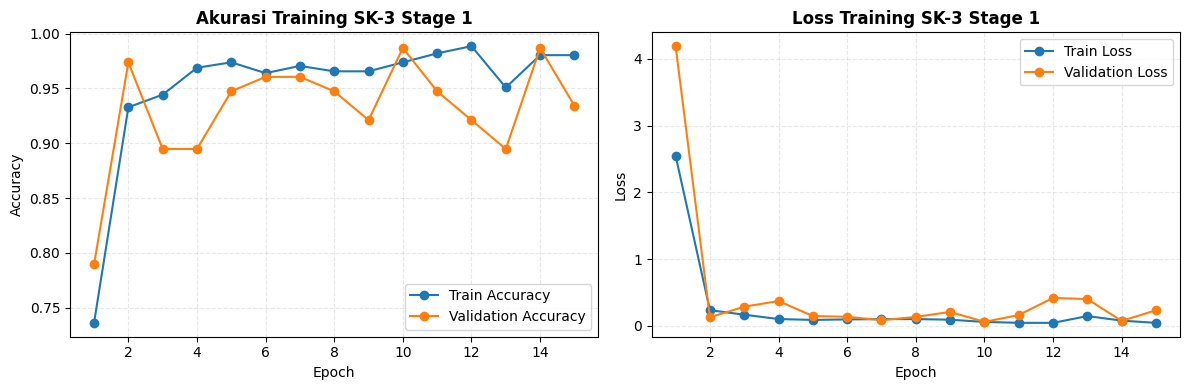

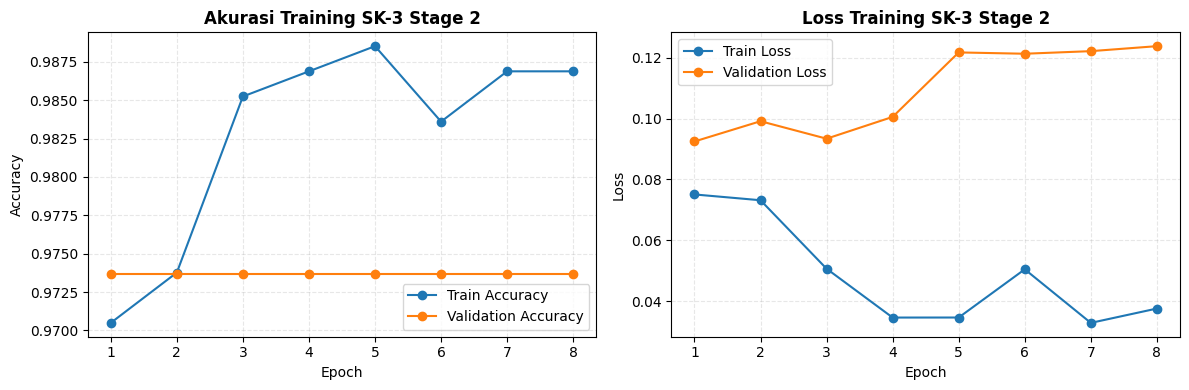

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
Hasil evaluasi model pada data test:
Akurasi  : 0.9870
Precision: 0.9892
Recall   : 0.9889
F1-Score : 0.9889

Classification Report:
                                   precision    recall  f1-score   support

            Biru (Pavo Cristatus)     0.9677    1.0000    0.9836        30
             Hijau (Pavo Muticus)     1.0000    0.9667    0.9831        30
Ungu (Pavo Cristatus mut. purple)     1.0000    1.0000    1.0000        17

                         accuracy                         0.9870        77
                        macro avg     0.9892    0.9889    0.9889        77
                     weighted avg     0.9874    0.9870    0.9870        77



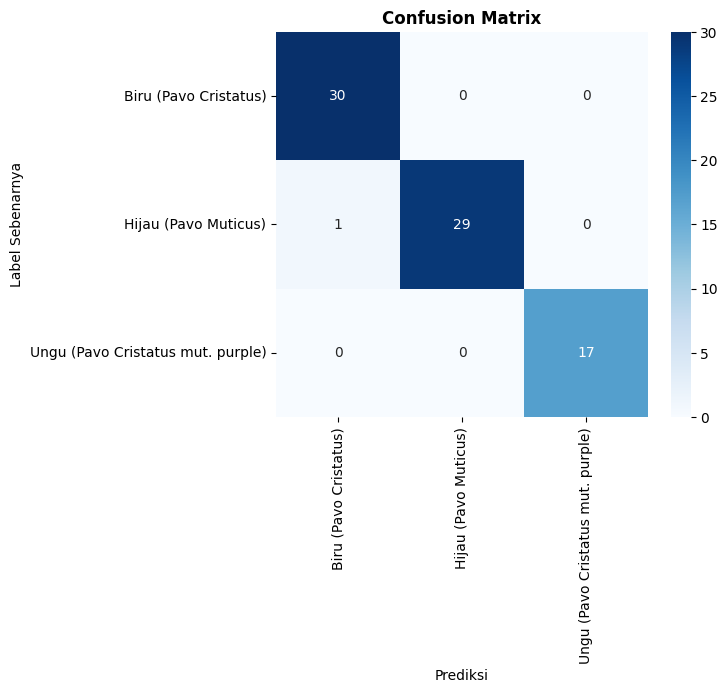

Evaluasi SK-3 selesai.


In [ ]:
steps_per_epoch_sk3_stage2 = len(train_generator)

print(f"Steps per epoch SK-3 Stage 2: {steps_per_epoch_sk3_stage2}")

history_sk_3_stage2 = sk_3_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    steps_per_epoch=steps_per_epoch_sk3_stage2,
    callbacks=sk_3_stage2_callbacks,
    verbose=1
)

# Visualisasi history training
plot_training_history(history_sk_3_stage1, title_suffix="SK-3 Stage 1")
plot_training_history(history_sk_3_stage2, title_suffix="SK-3 Stage 2")

# Evaluasi model pada data test
sk_3_metrics = evaluate_model(
    model=sk_3_model,
    test_generator=test_generator,
    class_names=class_names
)

print("Evaluasi SK-3 selesai.")

## 16. Rekap Hasil SK

#### Rekap metrik 3 skenario SK

In [ ]:
# Ambil metrik validation terbaik
sk1_best_epoch, sk1_best_val_loss, sk1_best_val_acc = get_best_val_metrics(history_sk_1)
sk2_best_epoch, sk2_best_val_loss, sk2_best_val_acc = get_best_val_metrics(history_sk_2_stage2)
sk3_best_epoch, sk3_best_val_loss, sk3_best_val_acc = get_best_val_metrics(history_sk_3_stage2)

# Buat tabel rekap hasil SK
sk_results_df = pd.DataFrame([
    {
        "Skenario": "SK-1",
        "Strategi": "Freeze Total",
        "Best Epoch": sk1_best_epoch,
        "Best Val Loss": round(sk1_best_val_loss, 4) if sk1_best_val_loss is not None else None,
        "Best Val Accuracy": round(sk1_best_val_acc, 4) if sk1_best_val_acc is not None else None,
        "Test Accuracy": round(sk_1_metrics["accuracy"], 4),
        "Precision Macro": round(sk_1_metrics["precision_macro"], 4),
        "Recall Macro": round(sk_1_metrics["recall_macro"], 4),
        "F1 Macro": round(sk_1_metrics["f1_macro"], 4)
    },
    {
        "Skenario": "SK-2",
        "Strategi": "Partial Fine-Tuning",
        "Best Epoch": sk2_best_epoch,
        "Best Val Loss": round(sk2_best_val_loss, 4) if sk2_best_val_loss is not None else None,
        "Best Val Accuracy": round(sk2_best_val_acc, 4) if sk2_best_val_acc is not None else None,
        "Test Accuracy": round(sk_2_metrics["accuracy"], 4),
        "Precision Macro": round(sk_2_metrics["precision_macro"], 4),
        "Recall Macro": round(sk_2_metrics["recall_macro"], 4),
        "F1 Macro": round(sk_2_metrics["f1_macro"], 4)
    },
    {
        "Skenario": "SK-3",
        "Strategi": "Full Fine-Tuning",
        "Best Epoch": sk3_best_epoch,
        "Best Val Loss": round(sk3_best_val_loss, 4) if sk3_best_val_loss is not None else None,
        "Best Val Accuracy": round(sk3_best_val_acc, 4) if sk3_best_val_acc is not None else None,
        "Test Accuracy": round(sk_3_metrics["accuracy"], 4),
        "Precision Macro": round(sk_3_metrics["precision_macro"], 4),
        "Recall Macro": round(sk_3_metrics["recall_macro"], 4),
        "F1 Macro": round(sk_3_metrics["f1_macro"], 4)
    }
])

print("Rekap hasil eksperimen SK:")
display(sk_results_df)

Rekap hasil eksperimen SK:


,Skenario,Strategi,Best Epoch,Best Val Loss,Best Val Accuracy,Test Accuracy,Precision Macro,Recall Macro,F1 Macro
0,SK-1,Freeze Total,7,0.0712,0.9737,0.974,0.9778,0.9778,0.9778
1,SK-2,Partial Fine-Tuning,1,0.1133,0.9605,0.987,0.9892,0.9889,0.9889
2,SK-3,Full Fine-Tuning,1,0.0925,0.9737,0.987,0.9892,0.9889,0.9889


#### Visualisasi perbandingan hasil SK

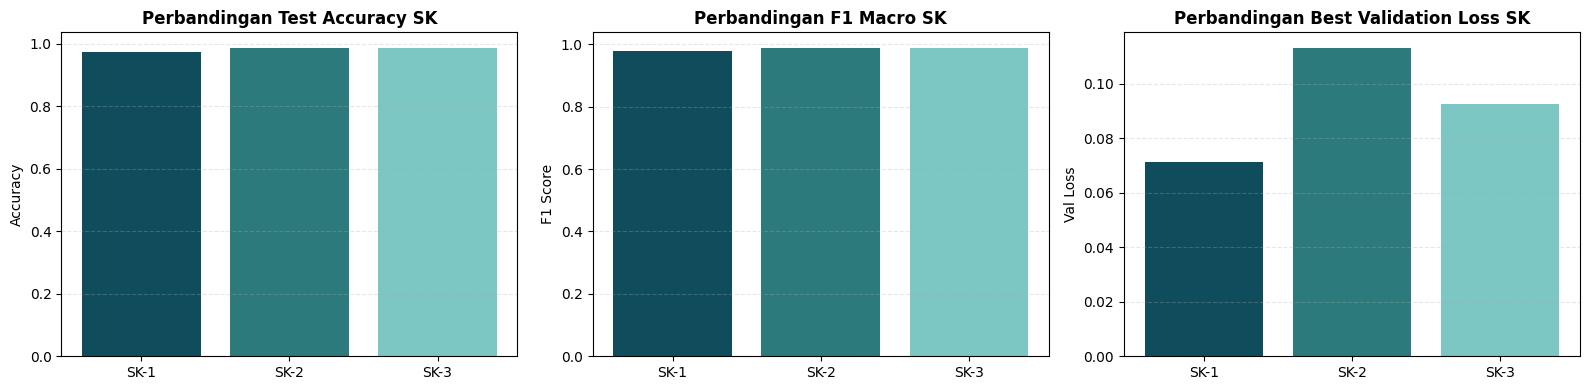

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Palet warna satu tone
colors = ["#0F4C5C", "#2C7A7B", "#7CC6C4"]

# Grafik Test Accuracy
axes[0].bar(sk_results_df["Skenario"], sk_results_df["Test Accuracy"], color=colors)
axes[0].set_title("Perbandingan Test Accuracy SK", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# Grafik F1 Macro
axes[1].bar(sk_results_df["Skenario"], sk_results_df["F1 Macro"], color=colors)
axes[1].set_title("Perbandingan F1 Macro SK", fontweight="bold")
axes[1].set_ylabel("F1 Score")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

# Grafik Best Validation Loss
axes[2].bar(sk_results_df["Skenario"], sk_results_df["Best Val Loss"], color=colors)
axes[2].set_title("Perbandingan Best Validation Loss SK", fontweight="bold")
axes[2].set_ylabel("Val Loss")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Rekap akhir baseline vs SK

#### Rekap akhir baseline vs SK

In [ ]:
# Gabungkan hasil baseline dan SK
final_comparison_df = pd.concat(
    [baseline_results_df, sk_results_df],
    ignore_index=True
)

print("Rekap akhir perbandingan baseline vs SK:")
display(final_comparison_df)

Rekap akhir perbandingan baseline vs SK:


,Skenario,Strategi,Best Epoch,Best Val Loss,Best Val Accuracy,Test Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Baseline-1,Freeze Total,6,0.1238,0.9342,0.961,0.9670,0.9667,0.9667
1,Baseline-2,Partial Fine-Tuning,13,0.2137,0.9474,0.961,0.9670,0.9667,0.9667
2,Baseline-3,Full Fine-Tuning,8,0.1503,0.9605,0.974,0.9778,0.9778,0.9778
3,SK-1,Freeze Total,7,0.0712,0.9737,0.974,0.9778,0.9778,0.9778
4,SK-2,Partial Fine-Tuning,1,0.1133,0.9605,0.987,0.9892,0.9889,0.9889
5,SK-3,Full Fine-Tuning,1,0.0925,0.9737,0.987,0.9892,0.9889,0.9889


#### Visualisasi perbandingan akhir

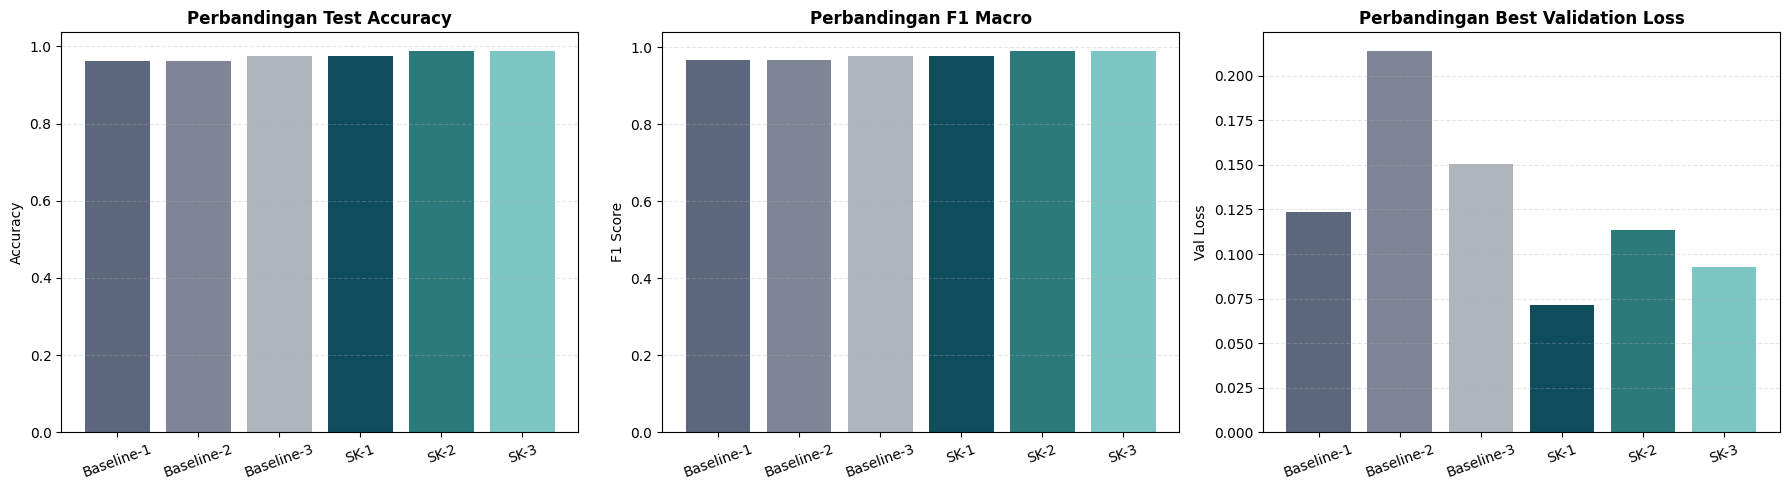

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Warna untuk baseline dan SK
colors = [
    "#5C677D", "#7D8597", "#ADB5BD",   # baseline
    "#0F4C5C", "#2C7A7B", "#7CC6C4"    # SK
]

# Grafik Test Accuracy
axes[0].bar(final_comparison_df["Skenario"], final_comparison_df["Test Accuracy"], color=colors)
axes[0].set_title("Perbandingan Test Accuracy", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].tick_params(axis="x", rotation=20)

# Grafik F1 Macro
axes[1].bar(final_comparison_df["Skenario"], final_comparison_df["F1 Macro"], color=colors)
axes[1].set_title("Perbandingan F1 Macro", fontweight="bold")
axes[1].set_ylabel("F1 Score")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)

# Grafik Best Validation Loss
axes[2].bar(final_comparison_df["Skenario"], final_comparison_df["Best Val Loss"], color=colors)
axes[2].set_title("Perbandingan Best Validation Loss", fontweight="bold")
axes[2].set_ylabel("Val Loss")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 18. Analisis Inference Time Model

###### Pengujian waktu inferensi dilakukan untuk mengetahui rata-rata waktu yang dibutuhkan model dalam menghasilkan prediksi terhadap satu citra masukan. Pengujian dilakukan pada model terbaik dari setiap skenario menggunakan data pengujian yang sama. Sebelum pencatatan waktu dilakukan, model menjalani warm-up prediction agar waktu inisialisasi awal tidak memengaruhi hasil pengukuran.

#### Daftar Model dan Fungsi Pengukuran Waktu Inferensi

In [ ]:
import time
import gc

# Daftar model terbaik dari setiap skenario yang akan diuji
inference_model_paths = {
    "Baseline-1": str(DATASET_DIR.parent / "baseline_1_best.keras"),
    "Baseline-2": str(DATASET_DIR.parent / "baseline_2_stage2_best.keras"),
    "Baseline-3": str(DATASET_DIR.parent / "baseline_3_stage2_best.keras"),
    "SK-1": str(DATASET_DIR.parent / "sk_1_best.keras"),
    "SK-2": str(DATASET_DIR.parent / "sk_2_stage2_best.keras"),
    "SK-3": str(DATASET_DIR.parent / "sk_3_stage2_best.keras")
}

# Konfigurasi pengujian waktu inferensi
warmup_runs = 5
max_test_samples = None   # None = gunakan seluruh data test

print("Daftar model untuk pengujian waktu inferensi:")
for scenario, path in inference_model_paths.items():
    status = "ditemukan" if Path(path).exists() else "tidak ditemukan"
    print(f"{scenario:<10} : {path} [{status}]")

print("\nKonfigurasi pengujian:")
print(f"Warm-up prediction : {warmup_runs} kali")
print(f"Jumlah data uji    : {'seluruh data test' if max_test_samples is None else max_test_samples}")


def load_and_preprocess_single_image(image_path, img_size):
    """
    Membaca dan memproses satu citra agar sesuai dengan input ResNet-50.

    Parameter:
    - image_path: path citra yang akan diproses
    - img_size  : ukuran input model, misalnya (224, 224)

    Return:
    - img_array: array citra dengan shape (1, height, width, 3)
    """

    img = Image.open(image_path).convert("RGB")
    img = img.resize(img_size)

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    return img_array


def measure_inference_time(model_path, test_df, img_size, warmup_runs=5, max_samples=None):
    """
    Mengukur waktu inferensi rata-rata model pada data test.

    Pengukuran dilakukan pada proses prediksi model saja.
    Proses loading citra dan preprocessing tidak dihitung ke dalam waktu inferensi.

    Parameter:
    - model_path   : path file model .keras
    - test_df      : DataFrame data test dengan kolom filepath dan label
    - img_size     : ukuran input model
    - warmup_runs  : jumlah warm-up prediction sebelum pencatatan waktu
    - max_samples  : jumlah maksimum sampel test yang digunakan

    Return:
    - dictionary berisi ringkasan waktu inferensi
    """

    # Pastikan file model tersedia
    if not Path(model_path).exists():
        raise FileNotFoundError(f"Model tidak ditemukan: {model_path}")

    # Load model dari file .keras
    model = tf.keras.models.load_model(model_path, compile=False, safe_mode=False)

    # Ambil data test yang akan digunakan
    if max_samples is None:
        sample_df = test_df.reset_index(drop=True).copy()
    else:
        sample_df = test_df.sample(
            n=min(max_samples, len(test_df)),
            random_state=42
        ).reset_index(drop=True)

    # Preload seluruh citra agar waktu baca file dan preprocessing tidak masuk pengukuran
    test_images = []
    for image_path in sample_df["filepath"]:
        img_array = load_and_preprocess_single_image(image_path, img_size)
        test_images.append(img_array)

    # Warm-up prediction untuk mengurangi pengaruh inisialisasi awal
    warmup_image = test_images[0]
    for _ in range(warmup_runs):
        _ = model.predict(warmup_image, verbose=0)

    # Pengukuran waktu inferensi per citra
    inference_times = []

    for img_array in test_images:
        start_time = time.perf_counter()
        _ = model.predict(img_array, verbose=0)
        end_time = time.perf_counter()

        inference_times.append(end_time - start_time)

    # Konversi ke array untuk perhitungan statistik
    inference_times = np.array(inference_times)

    result = {
        "Jumlah Sampel": len(test_images),
        "Avg Inference Time (s)": np.mean(inference_times),
        "Std Inference Time (s)": np.std(inference_times),
        "Min Inference Time (s)": np.min(inference_times),
        "Max Inference Time (s)": np.max(inference_times),
        "Avg Inference Time (ms)": np.mean(inference_times) * 1000,
        "Std Inference Time (ms)": np.std(inference_times) * 1000,
        "Min Inference Time (ms)": np.min(inference_times) * 1000,
        "Max Inference Time (ms)": np.max(inference_times) * 1000
    }

    # Bersihkan model dari memori setelah selesai diuji
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return result

print("\nFungsi pengukuran waktu inferensi berhasil dibuat.")

Daftar model untuk pengujian waktu inferensi:
Baseline-1 : /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras [ditemukan]
Baseline-2 : /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage2_best.keras [ditemukan]
Baseline-3 : /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage2_best.keras [ditemukan]
SK-1       : /content/drive/MyDrive/KodeScript-Arya/sk_1_best.keras [ditemukan]
SK-2       : /content/drive/MyDrive/KodeScript-Arya/sk_2_stage2_best.keras [ditemukan]
SK-3       : /content/drive/MyDrive/KodeScript-Arya/sk_3_stage2_best.keras [ditemukan]

Konfigurasi pengujian:
Warm-up prediction : 5 kali
Jumlah data uji    : seluruh data test

Fungsi pengukuran waktu inferensi berhasil dibuat.


#### Pengujian Waktu Inferensi pada Seluruh Skenario

In [ ]:
inference_results = []

for scenario, model_path in inference_model_paths.items():
    print(f"\nMengukur waktu inferensi: {scenario}")
    print(f"Path model: {model_path}")

    try:
        result = measure_inference_time(
            model_path=model_path,
            test_df=test_df,
            img_size=img_size,
            warmup_runs=warmup_runs,
            max_samples=max_test_samples
        )

        result["Skenario"] = scenario
        result["Model Path"] = model_path
        inference_results.append(result)

        print(f"Selesai: {scenario}")
        print(f"Rata-rata inference time: {result['Avg Inference Time (ms)']:.4f} ms")
        print(f"Standar deviasi         : {result['Std Inference Time (ms)']:.4f} ms")

    except Exception as e:
        print(f"Gagal mengukur {scenario}: {e}")

# Buat DataFrame hasil pengujian
inference_time_df = pd.DataFrame(inference_results)

if not inference_time_df.empty:
    inference_time_df = inference_time_df[
        [
            "Skenario",
            "Jumlah Sampel",
            "Avg Inference Time (ms)",
            "Std Inference Time (ms)",
            "Min Inference Time (ms)",
            "Max Inference Time (ms)",
            "Avg Inference Time (s)",
            "Std Inference Time (s)",
            "Min Inference Time (s)",
            "Max Inference Time (s)",
            "Model Path"
        ]
    ]

    print("\nRekap hasil pengujian waktu inferensi:")
    display(inference_time_df)

    # Simpan hasil pengujian ke file CSV
    inference_time_csv_path = DATASET_DIR.parent / "inference_time_results.csv"
    inference_time_df.to_csv(inference_time_csv_path, index=False)

    print(f"Hasil inference time disimpan ke: {inference_time_csv_path}")
else:
    print("Tidak ada hasil inference time yang berhasil dihitung.")


Mengukur waktu inferensi: Baseline-1
Path model: /content/drive/MyDrive/KodeScript-Arya/baseline_1_best.keras
Selesai: Baseline-1
Rata-rata inference time: 90.5595 ms
Standar deviasi         : 15.7567 ms

Mengukur waktu inferensi: Baseline-2
Path model: /content/drive/MyDrive/KodeScript-Arya/baseline_2_stage2_best.keras
Selesai: Baseline-2
Rata-rata inference time: 91.3863 ms
Standar deviasi         : 8.3560 ms

Mengukur waktu inferensi: Baseline-3
Path model: /content/drive/MyDrive/KodeScript-Arya/baseline_3_stage2_best.keras
Selesai: Baseline-3
Rata-rata inference time: 105.1417 ms
Standar deviasi         : 20.5006 ms

Mengukur waktu inferensi: SK-1
Path model: /content/drive/MyDrive/KodeScript-Arya/sk_1_best.keras
Selesai: SK-1
Rata-rata inference time: 128.2500 ms
Standar deviasi         : 31.6142 ms

Mengukur waktu inferensi: SK-2
Path model: /content/drive/MyDrive/KodeScript-Arya/sk_2_stage2_best.keras
Selesai: SK-2
Rata-rata inference time: 130.8316 ms
Standar deviasi         :

,Skenario,Jumlah Sampel,Avg Inference Time (ms),Std Inference Time (ms),Min Inference Time (ms),Max Inference Time (ms),Avg Inference Time (s),Std Inference Time (s),Min Inference Time (s),Max Inference Time (s),Model Path
0,Baseline-1,77,90.559488,15.756725,78.994149,147.336182,0.090559,0.015757,0.078994,0.147336,/content/drive/MyDrive/KodeScript-Arya/baselin...
1,Baseline-2,77,91.386301,8.356020,81.300472,132.872314,0.091386,0.008356,0.081300,0.132872,/content/drive/MyDrive/KodeScript-Arya/baselin...
2,Baseline-3,77,105.141722,20.500635,81.884666,156.823306,0.105142,0.020501,0.081885,0.156823,/content/drive/MyDrive/KodeScript-Arya/baselin...
3,SK-1,77,128.249954,31.614176,104.906744,231.290906,0.128250,0.031614,0.104907,0.231291,/content/drive/MyDrive/KodeScript-Arya/sk_1_be...
4,SK-2,77,130.831569,37.582151,104.792236,234.866322,0.130832,0.037582,0.104792,0.234866,/content/drive/MyDrive/KodeScript-Arya/sk_2_st...
5,SK-3,77,127.392727,26.243552,105.748167,214.128433,0.127393,0.026244,0.105748,0.214128,/content/drive/MyDrive/KodeScript-Arya/sk_3_st...


Hasil inference time disimpan ke: /content/drive/MyDrive/KodeScript-Arya/inference_time_results.csv


#### Visualisasi dan Rekap Akhir Waktu Inferensi

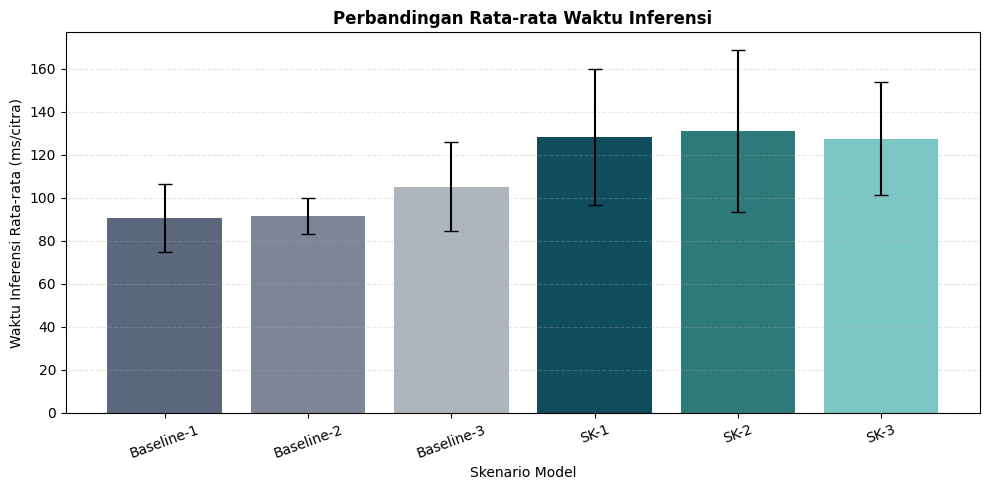

Rekap akhir model dengan waktu inferensi:


,Skenario,Strategi,Best Epoch,Best Val Loss,Best Val Accuracy,Test Accuracy,Precision Macro,Recall Macro,F1 Macro,Avg Inference Time (ms),Std Inference Time (ms),Min Inference Time (ms),Max Inference Time (ms)
0,Baseline-1,Freeze Total,6,0.1238,0.9342,0.961,0.9670,0.9667,0.9667,90.559488,15.756725,78.994149,147.336182
1,Baseline-2,Partial Fine-Tuning,13,0.2137,0.9474,0.961,0.9670,0.9667,0.9667,91.386301,8.356020,81.300472,132.872314
2,Baseline-3,Full Fine-Tuning,8,0.1503,0.9605,0.974,0.9778,0.9778,0.9778,105.141722,20.500635,81.884666,156.823306
3,SK-1,Freeze Total,7,0.0712,0.9737,0.974,0.9778,0.9778,0.9778,128.249954,31.614176,104.906744,231.290906
4,SK-2,Partial Fine-Tuning,1,0.1133,0.9605,0.987,0.9892,0.9889,0.9889,130.831569,37.582151,104.792236,234.866322
5,SK-3,Full Fine-Tuning,1,0.0925,0.9737,0.987,0.9892,0.9889,0.9889,127.392727,26.243552,105.748167,214.128433


Rekap akhir dengan waktu inferensi disimpan ke: /content/drive/MyDrive/KodeScript-Arya/final_comparison_with_inference_time.csv


In [ ]:
if not inference_time_df.empty:

    # Visualisasi rata-rata waktu inferensi setiap skenario
    plt.figure(figsize=(10, 5))

    colors = [
        "#5C677D", "#7D8597", "#ADB5BD",   # baseline
        "#0F4C5C", "#2C7A7B", "#7CC6C4"    # SK
    ]

    plt.bar(
        inference_time_df["Skenario"],
        inference_time_df["Avg Inference Time (ms)"],
        yerr=inference_time_df["Std Inference Time (ms)"],
        capsize=5,
        color=colors[:len(inference_time_df)]
    )

    plt.title("Perbandingan Rata-rata Waktu Inferensi", fontweight="bold")
    plt.xlabel("Skenario Model")
    plt.ylabel("Waktu Inferensi Rata-rata (ms/citra)")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    # Gabungkan hasil waktu inferensi ke rekap akhir baseline vs SK
    final_comparison_with_time_df = final_comparison_df.merge(
        inference_time_df[
            [
                "Skenario",
                "Avg Inference Time (ms)",
                "Std Inference Time (ms)",
                "Min Inference Time (ms)",
                "Max Inference Time (ms)"
            ]
        ],
        on="Skenario",
        how="left"
    )

    print("Rekap akhir model dengan waktu inferensi:")
    display(final_comparison_with_time_df)

    # Simpan rekap akhir dengan waktu inferensi
    final_comparison_with_time_csv_path = DATASET_DIR.parent / "final_comparison_with_inference_time.csv"
    final_comparison_with_time_df.to_csv(final_comparison_with_time_csv_path, index=False)

    print(f"Rekap akhir dengan waktu inferensi disimpan ke: {final_comparison_with_time_csv_path}")

else:
    print("Visualisasi tidak dibuat karena inference_time_df masih kosong.")

## 19. Simpan Model Final Terbaik

#### Tentukan model final yang dipilih

In [ ]:
final_model_name = "sk_2_stage2_best"   # pilih model terbaik
final_model_path = DATASET_DIR.parent / "sk_2_stage2_best.keras"

# Nama file model final yang lebih rapi
final_export_path = DATASET_DIR.parent / "model_deployment.keras"

print("Model final yang dipilih:")
print(f"Nama model : {final_model_name}")
print(f"Sumber     : {final_model_path}")
print(f"Export ke  : {final_export_path}")

Model final yang dipilih:
Nama model : sk_2_stage2_best
Sumber     : /content/drive/MyDrive/KodeScript-Arya/sk_2_stage2_best.keras
Export ke  : /content/drive/MyDrive/KodeScript-Arya/model_deployment.keras


#### Simpan / salin model final dengan nama akhir

In [ ]:
# Load model terbaik yang dipilih
final_model = tf.keras.models.load_model(final_model_path, compile=False)

# Simpan ulang dengan nama final
final_model.save(final_export_path)

print("Model final berhasil disimpan ulang.")
print(f"Path model final: {final_export_path}")

Model final berhasil disimpan ulang.
Path model final: /content/drive/MyDrive/KodeScript-Arya/model_deployment.keras


## Buat Test Gambar Baru

Hasil prediksi:
Biru (Pavo Cristatus) : 0.0017 (0.17%)
Hijau (Pavo Muticus) : 0.0500 (5.00%)
Ungu (Pavo Cristatus mut. purple) : 0.9483 (94.83%)

Prediksi akhir:
Kelas      : Ungu (Pavo Cristatus mut. purple)
Confidence : 0.9483 (94.83%)


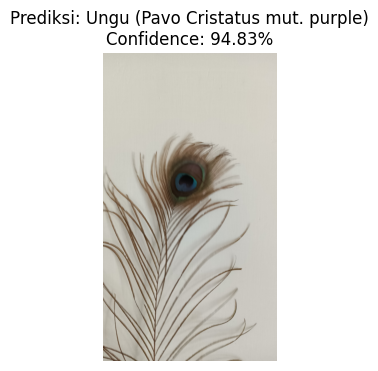

In [ ]:
# Path model dan gambar uji
model_path = DATASET_DIR.parent / "baseline_1_best.keras"
image_path = Path("/content/drive/MyDrive/KodeScript-Arya/ungu_uji.jpg")

# Load model
loaded_model = tf.keras.models.load_model(model_path, compile=False)

# Baca gambar asli
img = Image.open(image_path).convert("RGB")

# Resize sesuai input model
img_resized = img.resize(img_size)

# Ubah ke array lalu preprocess
img_array = np.array(img_resized, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Prediksi
pred = loaded_model.predict(img_array, verbose=0)
pred_idx = np.argmax(pred, axis=1)[0]
pred_label = class_names[pred_idx]
confidence = float(np.max(pred))

# Tampilkan semua probabilitas kelas
print("Hasil prediksi:")
for i, class_name in enumerate(class_names):
    print(f"{class_name:>10} : {pred[0][i]:.4f} ({pred[0][i]*100:.2f}%)")

print("\nPrediksi akhir:")
print(f"Kelas      : {pred_label}")
print(f"Confidence : {confidence:.4f} ({confidence*100:.2f}%)")

# Tampilkan gambar
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Prediksi: {pred_label}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()